# Notebook 02 — Generation of Main Manuscript Figures

## Purpose

This notebook reproduces all primary manuscript figures directly from the model outputs generated in Notebook 01. No model training is performed here; all figures are generated from the saved prediction results and cached feature matrices.

---

## Workflow

| Cell | Description |
|------|-------------|
| 1 | Repository setup and imports |
| 2 | Load prediction outputs and cached feature matrices |
| 3 | Figure configuration and helper functions |
| 4 | Load publication-ready datasets |
| 5 | Load Figure 4 feature-ablation summary |
| 6 | Prepare final prediction datasets |
| 7 | Generate Figure 4 (feature-ablation progression) |
| 8 | Generate Figures 5–7 (OOD prediction performance and calibration) |
| 9 | Export Supplementary Table S5 |
| 10 | Generate Supplementary Figure S7 (residual and uncertainty analysis) |
| 11 | Generate Figure 8 (global permutation feature importance) |

---

## Outputs

This notebook generates:

- Figure 4
- Figures 5–8
- Supplementary Figure S7
- Supplementary Table S5
- Figure 8 permutation importance table

All figures are written to the `outputs/figures/` directory and all supplementary tables are written to `outputs/supplementary_tables/`.

Run Notebook 01 before executing this notebook.

In [17]:
# ============================================================
# PROJECT SETUP
# ============================================================

import os
import sys
from pathlib import Path

CWD = Path.cwd().resolve()

candidates = [
    CWD,          # if notebook is launched from repo root
    CWD.parent,   # if notebook is launched from notebooks/
]

ROOT = None

for candidate in candidates:
    if (
        (candidate / "src").is_dir()
        and (candidate / "data").is_dir()
        and (candidate / "features").is_dir()
        and (candidate / "config.yaml").is_file()
    ):
        ROOT = candidate.resolve()
        break

if ROOT is None:
    raise RuntimeError(
        "Could not locate repository root.\n"
        "Expected folders: src/, data/, features/ and config.yaml\n"
        f"Notebook launched from: {CWD}"
    )

# Make all relative paths in legacy code resolve from repo root
os.chdir(ROOT)

# Make src modules importable
SRC_DIR = ROOT / "src"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ------------------------------------------------------------
# Load configuration
# ------------------------------------------------------------

from config import load_config

cfg = load_config(
    ROOT / "config.yaml",
    project_root_override=ROOT
)

DATA_DIR = ROOT / "data"
FEAT_DIR = ROOT / "features"

OUTPUT_DIR = ROOT / "outputs"

MODEL_DIR = OUTPUT_DIR / "model"
FIG_DIR = OUTPUT_DIR / "figures"
THERMO_CACHE_DIR = OUTPUT_DIR / "thermo_cache"
RESULTS_DIR_BASE = OUTPUT_DIR / "results"
SUPP_TABLE_DIR = OUTPUT_DIR / "supplementary_tables"

for d in [
    OUTPUT_DIR,
    MODEL_DIR,
    FIG_DIR,
    THERMO_CACHE_DIR,
    RESULTS_DIR_BASE,
    SUPP_TABLE_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = ROOT
ROOT_DIR = ROOT

# Some runner code expects this constant to exist
NORMALIZED_SNAPSHOT_SUFFIX = "__norm"

print("Repository root :", ROOT)
print("Data directory  :", DATA_DIR)
print("Feature directory:", FEAT_DIR)
print("Output directory:", ROOT / "outputs")

Repository root : /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy
Data directory  : /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/data
Feature directory: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features
Output directory: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/outputs


In [18]:
# === RUN CONFIG (thermo column overrides) ===
import thermo  

THERMO_ASO_COL_OVERRIDE     = "Sequence"
THERMO_TARGET_COL_OVERRIDE  = "target_window"

thermo.THERMO_ASO_COL_OVERRIDE = THERMO_ASO_COL_OVERRIDE
thermo.THERMO_TARGET_COL_OVERRIDE = THERMO_TARGET_COL_OVERRIDE

print("[thermo][override] ASO =", thermo.THERMO_ASO_COL_OVERRIDE,
      " TARGET =", thermo.THERMO_TARGET_COL_OVERRIDE)

[thermo][override] ASO = Sequence  TARGET = target_window


In [19]:
# === Preflight (input files) ===
from preflight import check_inputs, print_lab_columns

need = ["relative_expression.csv", "DAZ_top5.tsv", "FAM_top5.tsv"]
exists = check_inputs(need, base=DATA_DIR)
print("[preflight] exists:", {k: bool(v) for k, v in exists.items()})

print_lab_columns(DATA_DIR / "relative_expression.csv")


[preflight] exists: {'relative_expression.csv': True, 'DAZ_top5.tsv': True, 'FAM_top5.tsv': True}
[lab columns]: ['target', 'ID', 'group', 'rel_expr']


['target', 'ID', 'group', 'rel_expr']

In [20]:
# == Import modules (from src/) ==
import json
import pandas as pd
import numpy as np

from utils import make_run_id, run_paths, compute_map_sig, build_results_dir, safe_mkdir, assert_safe_to_write, config_get
from io_frames import build_merged
from features import ensure_sequence_column, finalize_and_save_features
from design_matrix import choose_and_build_design
from synthetic import make_synthetic_training
from thermo import compute_thermo_features, thermo_upgrade_section3
from mapping import map_and_access

from train_eval import (
    fit_ridge_logit, loocv_metrics_real_only, relative_loocv_logo,
    run_ablation_and_logo, save_calibration_plot, loocv_mae_r2,
    rmse, calibration_stats, permutation_baseline_spearman, summarize_logo_csv
)

from models import add_partial_pooling_X
from train_eval_resid import fit_ridge_residualized_cv, fit_pairwise_logit_cv

print("[imports] ok")

[imports] ok


In [21]:
# === Select cached thermo snapshot used for Phase 6 ===
from pathlib import Path

SNAP_DIR = FEAT_DIR / "snapshots"

GOLD = SNAP_DIR / "aso_features_phase10b_with_thermo.csv"

if not GOLD.exists():
    raise FileNotFoundError(
        f"Required cached feature snapshot not found: {GOLD}"
    )

print("[snapshots] GOLD:", GOLD)
print("[snapshots] GOLD exists?", GOLD.exists())

[snapshots] GOLD: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/snapshots/aso_features_phase10b_with_thermo.csv
[snapshots] GOLD exists? True


In [22]:

# ========= MASTER RUNNER (explicit Steps 1 → 8) =========

def run_pipeline(
    sim_mode: str = "basic",                # "basic" | "enhanced" | "synthetic"
    relative: bool = False,                 # absolute KD vs relative-KD evaluation
    ridge_alpha: float = 1.0,
    synth_n_per_real: int = 100,
    synth_weight: float = 0.3,
    noise_sigma0: float = 0.03, noise_c1: float = 0.07, noise_c2: float = 0.05,
    run_ablation: bool = True,
    run_logo: bool = True,
    full_bio: bool = False,                 # enforce Vienna-only in thermo
    thermo_cache: bool = True,              # use jsonl cache for thermo
    force_recompute_thermo: bool = False,
    verbose: bool = True,
    ROOT: Path | None = None,      # everything under Master_model/*
    phase: str | None = None,               # e.g., "P1", "P2", etc. (for run_id; optional)
    basic_feature_set: str | None = None,   # "proxy_only"|"proxy_duplex"|"proxy_duplex_access" (Phase-1 convenience)
    feat_path_override: Path | None = None, # flag for using basic snapshot for Phase1 to 3
    gold_path_override=None,                 # flag for using thermo snapshot - pass GOLD_FEATS here for P4–P6
    label_transform: str | None = None,
    calibration: str = "linear",
    calibration_scope: str = "global",      # for Phase 9
    partial_pooling: str | None = None,
):
    import json, pandas as pd, numpy as np
    from pathlib import Path
    
    if ROOT is None:
        ROOT = PROJECT_ROOT
    else:
        ROOT = Path(ROOT).resolve()
    
    # ensure suffix constant exists
    global NORMALIZED_SNAPSHOT_SUFFIX
    if 'NORMALIZED_SNAPSHOT_SUFFIX' not in globals():
        NORMALIZED_SNAPSHOT_SUFFIX = '__norm'
    
    sim_mode = sim_mode.lower().strip()
    assert sim_mode in {"basic","enhanced","synthetic"}, "sim_mode must be basic/enhanced/synthetic"
    if verbose:
        print(f"\n=== RUN PIPELINE ===\nmode={sim_mode}, relative={relative}\n")

    # --- Resolve project dirs ---
    DATA_DIR  = ROOT / "data"
    FEAT_DIR  = ROOT / "features"

    OUTPUT_DIR = ROOT / "outputs"
    MODEL_DIR = OUTPUT_DIR / "model"
    FIG_DIR = OUTPUT_DIR / "figures"
    THERMO_CACHE_DIR = OUTPUT_DIR / "thermo_cache"

    for d in [MODEL_DIR, FIG_DIR, THERMO_CACHE_DIR]:
        d.mkdir(parents=True, exist_ok=True)

    print (DATA_DIR)

    # normalize calibration early
    calibration = (calibration or "linear").lower()
    if calibration not in ("linear", "isotonic"):
        print(f"[warn] unknown calibration={calibration}; defaulting to 'linear'")
        calibration = "linear"
    print("[debug] calibration:", calibration, "feat_path_override:", feat_path_override)
    
    # normalize calibration scope early
    calibration_scope = (calibration_scope or "global").lower()
    if calibration_scope not in {"global", "by_family", "by_gene"}:
        print(f"[warn] unknown calibration_scope={calibration_scope}; defaulting to 'global'")
        calibration_scope = "global"
    print("[debug] calibration_scope:", calibration_scope)
    
    # Alias arg name used by drivers
    feature_set = basic_feature_set

    # ---------------- STEP 1 — Merge lab + designs ----------------
    # Reads LAB_CSV and the design TSVs from Master_model/data, writes merged_aso_results.csv
    merged = build_merged(
        lab_csv=DATA_DIR / "relative_expression.csv",
        designs=[DATA_DIR / "DAZ_top5.tsv", DATA_DIR / "FAM_top5.tsv"],
        data_dir=DATA_DIR,
        verbose=verbose,
    )

    print(f"[run_pipeline] label_transform={label_transform}")

    # ---------------- Prepare transcript FASTA paths ----------------
    # Your earlier lists were bare filenames; prefix them with DATA_DIR so mapping can find them.
    TRANSCRIPTS = {
        "DAZ": [
            DATA_DIR / "DAZ_MANE.fasta",
            DATA_DIR / "DAZ_A.fasta",
            DATA_DIR / "DAZ_B.fasta",
            DATA_DIR / "DAZ_C.fasta",
            DATA_DIR / "DAZ_D.fasta",
            DATA_DIR / "DAZ_E.fasta",
            DATA_DIR / "DAZ_F.fasta",
            DATA_DIR / "DAZ_G.fasta",
        ],

        "FAM": [
            DATA_DIR / "FAM_MANE.fasta",
            DATA_DIR / "FAM_A.fasta",
            DATA_DIR / "FAM_B.fasta",
            DATA_DIR / "FAM_C.fasta",
            DATA_DIR / "FAM_D.fasta",
        ],
        "TARDBP": [
            DATA_DIR/"TARDBP_NM_007375_MANE_Select.fasta",
        ],
        "SOD1": [
        DATA_DIR/"SOD1_MANE.fasta",
        ],
        "ATXN2": [
            DATA_DIR/"ATXN2_MANE.fasta",
        ],
        "C9ORF72": [
            DATA_DIR/"C9ORF72_MANE.fasta",
        ],
        "FUS": [
            DATA_DIR/"FUS_MANE.fasta",
        ],
        "STMN2": [
            DATA_DIR/"STMN2_MANE.fasta",
        ],
        "AR": [
            DATA_DIR/"AR_MANE.fasta",
        ],
        "UNC13A": [
            DATA_DIR/"UNC13A_MANE.fasta",
        ],
    }
    ALIASES = {
        "DAZ": "DAZ",
        "FAM": "FAM",
        "TARDBP": "TARDBP", "TDP-43": "TARDBP", "TDP43": "TARDBP",
    }
    # Training is inlined inside run_pipeline, just skip any Phase-9 / Step-3 code paths once 
    # feat_path_override is set, and drop directly into the “train” block.
    if feat_path_override:
        feat_path = Path(feat_path_override)
        df = pd.read_csv(feat_path)  # keep df in scope for later
        print(f"[Step-2] Using precomputed features from {feat_path}")

        # Fast-path flags: skip mapping/plfold and skip Step-3 thermo upgrade
        skip_step2_mapping = True
        skip_step3_thermo = True
    else:
        skip_step2_mapping = False
        skip_step3_thermo = False

    # ---------------- STEP 0.9 — Prepare run directories EARLY (needed by later steps) ----------------
    RUNS_DIR  = MODEL_DIR / "runs"
    RUNS_DIR.mkdir(parents=True, exist_ok=True)

    # Build a run_id early (if you already compute run_id elsewhere, it's fine to reuse that; this is a safe fallback)
    from datetime import datetime
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    phase_tag   = str(phase) if phase is not None else "P"
    feat_tag    = (feature_set or "feat")
    alpha_tag   = f"a{ridge_alpha}".replace(".", "p") if "ridge_alpha" in locals() else "a"
    run_id      = f"{phase_tag}__{feat_tag}__{alpha_tag}__{stamp}"

    # Define run dir and ensure it exists
    MODEL_RUN_DIR = RUNS_DIR / run_id
    MODEL_RUN_DIR.mkdir(parents=True, exist_ok=True)

    # (Optional) helpful debug so you can see it once per run
    print("[debug] MODEL_RUN_DIR:", MODEL_RUN_DIR)

    # ---------------- STEP 2 — Mapping + accessibility + finalize features ----------------
    snap2 = None  # <-- initialize so it's always defined
    if feat_path_override:
        # ===== FAST PATH: use precomputed snapshot as-is =====
        feat_path = Path(feat_path_override)
        df = pd.read_csv(feat_path)  # keep df around for downstream
        print(f"[Step-2] FAST PATH: using precomputed features from {feat_path}")

        # IMPORTANT:
        # - Do NOT run mapping/plfold
        # - Do NOT call add_phase9_features on top of a snapshot
        # - Do NOT call finalize_and_save_features on a snapshot
        #
        # If you want to allow Phase-9 on top of a snapshot in the future,
        # do it in Step-4 (design/build) behind an explicit flag, not here.

        # Let Step-3 know we already have features; it should usually be skipped
        # (Guard Step-3 with `and not skip_step3_thermo` where you enter Step-3.)
        skip_step3_thermo = True

    else:
        # ===== SLOW PATH: compute mapping/plfold, then finalize features =====
        df = ensure_sequence_column(merged)

        df = map_and_access(
            df,
            transcripts=TRANSCRIPTS,
            aliases=ALIASES,
            W=120, U=20,
            max_mismatches=3,
            use_duplex_fallback=True,
            compute_accessibility=True,
            verbose=verbose,
        )

        must = ["dG_open_mean", "dG_open_min", "neg_dG_eff", "target_gc_pm10", "target_gc_pm30"]
        print("missing:", [c for c in must if c not in df.columns])

        # Optional Phase-9 augmentation ONLY on freshly computed features
        if (feature_set or "").lower() == "p9_context":
            from features import add_phase9_features
            if not set(must).issubset(df.columns):
                df = add_phase9_features(
                    df,
                    context_windows=(10, 30),
                    k_orders=(2, 3),
                    kmer_pca_dims=10,
                )
                print("[P9] added features; now present:", [c for c in must if c in df.columns])
            else:
                print("[P9] features already present – skipping add_phase9_features()")

        # 2.4–2.5 finalize required columns & write features/aso_features.csv
        feat_path = finalize_and_save_features(
            df,
            feat_dir=FEAT_DIR,
            merged_for_kd=merged,
            verbose=verbose,
        )

        # ---- Step-2 snapshot (mapping/access provenance) ----
        MAP_SIG = compute_map_sig(df)
        max_mismatches_used = 3
        use_duplex_flag = 1
        use_access_flag = 1
        snap2 = FEAT_DIR / f"snapshots/aso_features_step2_map-{MAP_SIG}_mm{max_mismatches_used}_dup{use_duplex_flag}_acc{use_access_flag}.csv"
        snap2.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(snap2, index=False)

        # We computed features freshly, so Step-3 may run (thermo upgrade) if needed.
        skip_step3_thermo = False
        
        # 2.4–2.5 Fill required columns, merge KD if missing, and write features/aso_features.csv
        feat_path = finalize_and_save_features(
            df,
            feat_dir=FEAT_DIR,
            merged_for_kd=merged,
            verbose=verbose,
        )

        # ---- Step-2 snapshot (mapping/access) ----
        MAP_SIG = compute_map_sig(df)
        max_mismatches_used = 3
        use_duplex_flag = 1
        use_access_flag = 1
        snap2 = FEAT_DIR / f"snapshots/aso_features_step2_map-{MAP_SIG}_mm{max_mismatches_used}_dup{use_duplex_flag}_acc{use_access_flag}.csv"
        snap2.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(snap2, index=False)

    # ---------------- STEP 3 — Thermo upgrade (enhanced/synthetic only) ----------------
    # This faithfully reproduces your Section-3 (cache, Vienna-only guardrails, gold snapshot).
    gold_path = None
    print(f"[Step-3] gold_path_override set to: {gold_path_override}")
    
    def _has_thermo_columns(frame):
        cols = set(map(str.lower, frame.columns))
        return ("dg37_kcalmol" in cols) or ("neg_dg_bind" in cols and "duplex_dg" in cols)
    
    if sim_mode in {"enhanced", "synthetic"} and not skip_step3_thermo:
        # EARLY EXIT: if caller provided GOLD (or GOLD+kmers), do NOT thermo-upgrade or renormalize
        if gold_path_override is not None:
            feat_path = Path(gold_path_override)  # this is our active features file
            df = pd.read_csv(feat_path)
            # (optionally: light column sanity checks here)
            # then jump straight to Step-4
        else:
            # (A) If caller provided a gold snapshot, use it and skip compute.
            if gold_path_override is not None:
                gold_path = Path(gold_path_override)
                if not gold_path.exists():
                    raise FileNotFoundError(f"[Step-3] gold_path_override not found: {gold_path}")
                df = pd.read_csv(gold_path)
                feat_path = gold_path  # downstream uses this as the active feature set
                if verbose:
                    print(f"[Step-3] Using precomputed THERMO GOLD features from {gold_path}")

            # (B) Else, if current df already contains thermo columns, accept as gold.
            elif _has_thermo_columns(df):
                gold_path = feat_path  # whatever we loaded already has thermo
                if verbose:
                    print(f"[Step-3] Detected thermo columns in current features → treating as GOLD: {gold_path}")

            # (C) Else, upgrade Step-2 → thermo using helper (cache-aware)
            else:
                if verbose:
                    print("[Step-3] Upgrading Step-2 features to THERMO (ΔG°37) via thermo_upgrade_section3...")
                merged, thermo_feat_path, gold_path = thermo_upgrade_section3(
                    sim_mode=sim_mode,
                    feat_path=feat_path,
                    merged=merged,
                    features_dir=FEAT_DIR,
                    thermo_cache_dir=THERMO_CACHE_DIR,
                    full_bio=full_bio,
                    thermo_cache=thermo_cache,
                    force_recompute_thermo=force_recompute_thermo,
                    verbose=verbose,
                )
                # To train against gold_path directly, set:
                feat_path = Path(gold_path) if gold_path is not None else Path(feat_path)   # <<< ensure Path; DO NOT override with thermo_feat_path

        # ---- P10b: ensure required thermo-derived columns exist on-disk and in-memory ----
        feat_path = Path(feat_path)                                                     # <<< ensure Path for any branch (A/B/C)
        df = pd.read_csv(feat_path)

        # 1) neg_dG_bind = - dG37_kcalmol
        if "neg_dG_bind" not in df.columns:
            # Handle common naming variants just in case:
            dG_candidates = [c for c in df.columns if c.lower() in {"dg37_kcalmol", "dg37", "dg_duplex_37", "duplex_dg37"}]
            if not dG_candidates:
                raise KeyError("Thermo CSV missing ΔG°37 column; expected one of: dG37_kcalmol / dG37 / dg_duplex_37 / duplex_dG37")
            dG_col = dG_candidates[0]
            df["neg_dG_bind"] = -df[dG_col]

        # 2) (optional) neg_dG_eff = -(dG37 - dG_open_mean)
        if "neg_dG_eff" not in df.columns and "dG_open_mean" in df.columns:
            dG_col = [c for c in df.columns if c.lower() in {"dg37_kcalmol", "dg37", "dg_duplex_37", "duplex_dg37"}][0]
            df["neg_dG_eff"] = -(df[dG_col] - df["dG_open_mean"])

        # Normalize thermo column name (idempotent)
        if "dg37_kcalmol" in df.columns and "dG37_kcalmol" not in df.columns:
            df = df.rename(columns={"dg37_kcalmol": "dG37_kcalmol"})

        # Enforce neg_dG_bind = -dG37_kcalmol when dG37 is present
        if "dG37_kcalmol" in df.columns:
            df["dG37_kcalmol"] = pd.to_numeric(df["dG37_kcalmol"], errors="coerce")
            df["neg_dG_bind"]  = -df["dG37_kcalmol"]
            _diff = (df["neg_dG_bind"] + df["dG37_kcalmol"]).abs().max(skipna=True)
            if _diff > 1e-3 and verbose:
                print(f"[Step-3][note] normalized neg_dG_bind from dG37 (post-fix diff={_diff:.4f})")

            # --- write a normalized copy next to the original ---
            feat_path = Path(feat_path)
            if isinstance(NORMALIZED_SNAPSHOT_SUFFIX, str):
                out_path = feat_path.with_name(feat_path.stem + NORMALIZED_SNAPSHOT_SUFFIX + feat_path.suffix)
            else:
                out_path = feat_path.with_name(feat_path.stem + "__norm_v1" + feat_path.suffix)
            df.to_csv(out_path, index=False)
            if verbose:
                print(f"[Step-3] wrote normalized GOLD snapshot → {out_path}")
            feat_path = out_path                                        # <<< downstream uses the normalized file
        else:
            # Persist edits back to the same file if we didn't re-alias dG37
            df.to_csv(feat_path, index=False)

        # Re-read the active feature set path so downstream is consistent
        df = pd.read_csv(feat_path)

                    
    # ---------------- STEP 4 — Design matrix & scalers ----------------
    # If your thermo snapshot only has dG37, standardize neg_dG_bind now (safe no-op if present)
    if "dG37_kcalmol" in df.columns and "neg_dG_bind" not in df.columns:
        df["neg_dG_bind"] = -df["dG37_kcalmol"]

    # For synthetic runs, force relative=True to suppress target_* dummies
    relative_eff = True if (sim_mode == "synthetic") else relative

    # Build the design using your existing helper (this may add/transform columns)
    # If we had a snapshot override, force it here.
    if feat_path_override:
        feat_path = Path(feat_path_override)
    else:
        feat_path = Path(feat_path) if 'feat_path' in locals() and feat_path is not None else None

    if feat_path is not None:
        print(f"[run] Using snapshot features at {feat_path}")
        
        # >>> PHASE-9: augment old GOLD with P9 features, then point feat_path at the augmented CSV
        if (feature_set or "").lower() == "p9_context":
            from features import add_phase9_features
            need = {"dG_open_mean","dG_open_min","neg_dG_eff","aso_gc_frac","target_gc_pm10","target_gc_pm30"}

            # if the snapshot doesn't have P9 columns yet, add them
            if not need.issubset(set(df.columns)):
                df = add_phase9_features(df, context_windows=(10,30), k_orders=(2,3), kmer_pca_dims=10)
                # write the augmented frame to a run-local CSV and pass that into the design builder
                p9_feat_csv = Path(feat_path).with_name(Path(feat_path).stem + "__p9.csv")
                df.to_csv(p9_feat_csv, index=False)
                feat_path = p9_feat_csv
                print(f"[P9] augmented features written → {p9_feat_csv}")
    
    F, X_design, y, feature_order, core_feats = choose_and_build_design(
        feat_path=feat_path,
        model_dir=MODEL_RUN_DIR,
        relative=relative_eff,
        verbose=verbose,
        feature_set=feature_set,     # <— Phase 9
        use_gene_z=True,             # <— optional; on for P9
    )
    # >>> [OPTIONAL DEBUG]
    if (feature_set or "").lower() == "p9_context":
        print("[debug][train_eval] first cols:", X_design.columns.tolist()[:12], "… total:", len(X_design.columns))
    
    # --- Save a raw copy of F for relative evaluation later (Step-7a) ---
    F_raw_for_relative = F.copy()
    
    # >>> Add this block right here (before any calibration) <<<
    if "family" not in F_raw_for_relative.columns:
        # pick a source field we already have
        if "target" in F_raw_for_relative.columns:
            src = F_raw_for_relative["target"].astype(str)
        elif "gene" in F_raw_for_relative.columns:
            src = F_raw_for_relative["gene"].astype(str)
        else:
            src = None

        if src is None:
            F_raw_for_relative["family"] = "UNK"
        else:
            fam = src.str.upper().replace({
                "DAZ": "DAZ",
                "FAM": "FAM",
            })
            F_raw_for_relative["family"] = fam.fillna("UNK")

    # ---- Tier-based feature whitelist (do this ONCE, on X_design) ----    
    is_p9 = (str(basic_feature_set or "").lower() == "p9_context")
    is_proxy_mode = str(basic_feature_set or "").lower().startswith("proxy")
    if not is_p9 and is_proxy_mode:    
        def _feature_cols_for_set(basic_feature_set: str):
            cols = ["neg_dG_bind"]  # proxy in P1, thermo in P4+ (same name)
            fs = (basic_feature_set or "").lower()
            if "duplex" in fs:
                cols.append("neg_duplex_dG")
            if "access" in fs or "punp" in fs:
                cols.append("logit_punp")
            return cols

        strict = (sim_mode != "synthetic")  # be tolerant only in P7
        feature_cols = _feature_cols_for_set(basic_feature_set)

        # Force the thermo-era trio in enhanced/synthetic when feature_set is unspecified
        if sim_mode in {"enhanced", "synthetic"} and (basic_feature_set is None or str(basic_feature_set).strip()==""):
            feature_cols = ["neg_dG_bind", "neg_duplex_dG", "logit_punp"]

        missing = [c for c in feature_cols if c not in X_design.columns]
        if missing and strict:
            raise KeyError(f"Missing required features for set={basic_feature_set}: {missing}")
        elif missing:  # P7 synthetic: allow zero-fill
            for c in missing:
                if verbose: print(f"[design][synthetic] injecting missing column {c}=0.0")
                X_design[c] = 0.0

        # AFTER choose_and_build_design(...) and your whitelist on X_design
        feature_order = list(X_design.columns)  # overwrite to the whitelisted order
        core_feats    = list(X_design.columns)
        F = X_design.copy()  # make sure the "full frame" the trainer sees IS the whitelist

        # Drop any non-whitelisted columns so fit/predict schemas match exactly
        keep = [c for c in feature_cols if c in X_design.columns]
        X_design = X_design[keep]  # enforce order & subset

    # keep your Phase-1 convenience filters INSIDE the same if-not-is_p9 guard
    if not is_p9:
        # The whitelist already enforced exactly these subsets:
        # - proxy_only -> ["neg_dG_bind"]
        # - proxy_duplex -> ["neg_dG_bind","neg_duplex_dG"]
        # - proxy_duplex_access -> ["neg_dG_bind","neg_duplex_dG","logit_punp"]
        # ---- Phase-1 convenience filters  ----
        if basic_feature_set == "proxy_only":
            keep = ["neg_dG_bind"]; keep = [c for c in keep if c in X_design.columns]
            X_design = X_design[keep]; core_feats = keep[:]
        elif basic_feature_set == "proxy_duplex":
            keep = [c for c in ["neg_dG_bind","neg_duplex_dG"] if c in X_design.columns]
            X_design = X_design[keep]; core_feats = keep[:]
        elif basic_feature_set == "proxy_duplex_access":
            keep = [c for c in ["neg_dG_bind","neg_duplex_dG","logit_punp"] if c in X_design.columns]
            X_design = X_design[keep]; core_feats = keep[:]
    
    # --- Reset downstream variables after subsetting ---
    feature_order = list(X_design.columns)
    core_feats    = list(X_design.columns)
    F = X_design.copy()

    #print("[debug] sim_mode:", sim_mode,
    #    "feature_set:", basic_feature_set,
    #    "relative_eff:", relative_eff)
    #print("[debug] FINAL X_design cols:", list(X_design.columns))
    
    # Run ID + per-run folders
    use_duplex  = int("neg_duplex_dG" in X_design.columns)
    use_access  = int("logit_punp"    in X_design.columns)
    synthetic_tag = ("none" if sim_mode != "synthetic" else "A")
    run_id_base = make_run_id(
        phase=phase, mode=sim_mode, relative=relative_eff, alpha=ridge_alpha, ablation=bool(run_ablation),
        use_duplex=use_duplex, use_access=use_access, synthetic=synthetic_tag,
        synth_n_per_real=(synth_n_per_real if sim_mode=="synthetic" else None),
        synth_weight=(synth_weight if sim_mode=="synthetic" else None)
    )
    
    # --- finalize run_id (only add suffixes for Phase 8 variants) ---
    is_p8 = str(phase).lower().startswith("p8")

    if is_p8:
        if label_transform in ("pairwise_gene", "rank_gene", "pairwise"):      # P8b
            run_id = f"{run_id_base}__cal_{calibration}"                       # e.g., __cal_linear / __cal_isotonic
        elif label_transform in ("gene_resid", "residualize_gene", "resid_gene"):  # P8a residualized
            run_id = f"{run_id_base}__lt_resid"
        else:                                                                  # P8a identity (no transform)
            run_id = f"{run_id_base}__lt_identity"
    else:
        # All other phases (P1–P7, P9…) keep the original naming
        run_id = run_id_base

    # Create dirs ONCE, right after finalizing run_id
    MODEL_RUN_DIR, FIG_RUN_DIR = run_paths(OUTPUT_DIR, run_id)
    #print("[debug] final run_id:", run_id, "| MODEL_RUN_DIR:", MODEL_RUN_DIR.name)

    # (Optional check)
    if is_p8:
        if label_transform in ("pairwise_gene","rank_gene","pairwise"):
            assert "__cal_" in MODEL_RUN_DIR.name
        elif label_transform in ("gene_resid","residualize_gene","resid_gene"):
            assert "__lt_resid" in MODEL_RUN_DIR.name
        else:
            assert "__lt_identity" in MODEL_RUN_DIR.name
    
    # ---------------- PHASE 8a — Residualized labels + Ridge (conditional) ----------------
    if label_transform in ("gene_resid", "residualize_gene", "resid_gene"):
        # 8a.1 — Extract identifiers safely (gene, family) from the pre-whitelist frame
        def _safe_series(frame: pd.DataFrame, candidates, default):
            for c in candidates:
                if c in frame.columns:
                    return frame[c].astype(str).reset_index(drop=True)
            return pd.Series([default] * len(frame), dtype=str)

        gene_ids   = _safe_series(F_raw_for_relative, ["gene", "target_gene", "target"], default="UNK_GENE")
        family_ids = _safe_series(F_raw_for_relative, ["family", "target_family"], default="UNK_FAM")
        y_kd       = pd.Series(y).astype(float).reset_index(drop=True)

        # 8a.2 — Build LOGO folds by gene (or flip to LOOCV if you prefer)
        def make_logo_folds_by_gene(genes: pd.Series, min_train=2, min_test=1):
            folds = []
            n = len(genes)
            groups = genes.groupby(genes).groups
            for gname, idx in groups.items():
                test_idx  = np.array(sorted(list(idx)))
                train_idx = np.array(sorted(list(set(range(n)) - set(test_idx))))
                if len(test_idx) < min_test or len(train_idx) < min_train:
                    print(f"[P8a][fold-skip] gene={gname} test={len(test_idx)} train={len(train_idx)}")
                    continue
                folds.append((train_idx, test_idx))
            if not folds:
                print("[P8a][folds] No valid LOGO folds — falling back to LOOCV.")
                folds = [(np.array([j for j in range(n) if j != i]), np.array([i])) for i in range(n)]
            return folds

        folds = make_logo_folds_by_gene(gene_ids)

        # --- Optional partial pooling (random-intercept approximation via ridge on group dummies) ---
        # Prefer "gene" if available; otherwise fall back to "target" or "family".
        group_col = None
        for cand in ["gene", "target", "family"]:
            if cand in F_raw_for_relative.columns:
                group_col = cand
                break

        if partial_pooling == "gene_intercepts" and group_col is not None:
            # Build low-variance one-hot intercepts for the grouping column
            PP = add_partial_pooling_X(F_raw_for_relative, group_col)  # returns (n, k) matrix of 0/1 dummies
            # Name the columns and concat to the design matrix
            pp_cols = [f"pp__{group_col}__{g}" for g in pd.Categorical(F_raw_for_relative[group_col]).categories]
            PP_df  = pd.DataFrame(PP, index=X_design.index, columns=pp_cols)
            X_design = pd.concat([X_design, PP_df], axis=1)

            # Persist extended feature order for reproducibility
            feature_order = X_design.columns.tolist()
            with open(MODEL_RUN_DIR/ "feature_order.json", "w") as f:
                json.dump(feature_order, f, indent=2)

        # 8a.3 — Train residualized ridge via your helper
        alpha = float(ridge_alpha)
        summary = fit_ridge_residualized_cv(
            X=X_design.reset_index(drop=True),
            y=y_kd,
            genes=gene_ids,
            families=family_ids,
            folds=folds,
            alpha=alpha
        )

        #print("[P8a] MAE(abs):", summary.mae_abs_mean)
        #print("[P8a] R^2(abs):", summary.r2_abs_mean)
        #print("[P8a] Spearman within-gene (macro):", summary.spearman_within_macro)

        # 8a.4 — Persist outputs compatible with your runners
        p8a_summary_path = MODEL_RUN_DIR / "p8a_summary.json"
        with open(p8a_summary_path, "w") as f:
            json.dump({
                "phase": str(phase),
                "run_id": str(run_id),
                "alpha": alpha,
                "split_mode": "LOGO",
                "mae_abs_mean": summary.mae_abs_mean,
                "r2_abs_mean": summary.r2_abs_mean,
                "spearman_within_macro": summary.spearman_within_macro,
                "per_fold": [fr.__dict__ for fr in summary.per_fold],
            }, f, indent=2)

        # Also write metrics.json so your existing runners can read headline numbers
        metrics = {
            "phase": str(phase),
            "label_transform": "gene_resid",
            "LOOCV_MAE": summary.mae_abs_mean,   # keep the same key names your runner expects
            "LOOCV_R2":  summary.r2_abs_mean,
            "perm_spearman_mean": summary.spearman_within_macro,  # we reuse the field here
            "calibration_slope": None,
            "calibration_intercept": None,
        }
        metrics_path = MODEL_RUN_DIR / "metrics.json"
        with open(metrics_path, "w") as f:
            json.dump(metrics, f, indent=2)
        
        # --- Copy metrics.json to the run dir (residualized) ---
        try:
            (MODEL_RUN_DIR / "metrics.json").write_text(Path(metrics_path).read_text())
        except Exception as e:
            print(f"[P8a-resid][warn] couldn't copy metrics.json: {e}")

        # --- P8a: write features snapshot + run_meta before returning ---
        (FEAT_DIR / "runs" / run_id).mkdir(parents=True, exist_ok=True)
        # snapshot the features this run used; falls back to X if df isn't available
        (F if 'df' not in locals() else df).to_csv(FEAT_DIR / f"runs/{run_id}/features.csv", index=False)

        run_meta = {
            "run_id": run_id,
            "phase": phase, "mode": sim_mode, "relative": relative_eff, "alpha": ridge_alpha,
            "ablation": bool(run_ablation), "use_duplex": use_duplex, "use_access": use_access,
            "synthetic": synthetic_tag,
            "artifacts": {
                "metrics_json": str(metrics_path),
                "p8a_summary_json": str(p8a_summary_path),
                # useful provenance:
                "features_gold_snapshot": str(feat_path) if 'feat_path' in locals() and feat_path is not None else None,
            },
        }
        json.dump(run_meta, open(MODEL_RUN_DIR / "run_meta.json", "w"), indent=2)

        # Early return to skip the standard (non-residualized) training path
        return {
            "run_id": run_id,
            "model_run_dir": str(MODEL_RUN_DIR),
            "fig_run_dir": str(FIG_RUN_DIR),
            "metrics_json": str(metrics_path),
            "coef_csv": None,
            "predictions_csv": None,
            "ablation_csv": None,
            "logo_abs_csv": None,
            "logo_rel_csv": None,
            "calibration_png": None,
        }
    # ---------------- END PHASE 8a conditional ----------------
    
    # ---------------- PHASE 8b — Pairwise ranking within gene (conditional) ----------------
    if label_transform in ("pairwise_gene", "rank_gene", "pairwise"):
        import itertools, json
        from dataclasses import dataclass
        from typing import List, Tuple, Optional
        from sklearn.linear_model import LogisticRegression, LinearRegression
        from sklearn.isotonic import IsotonicRegression
        from scipy.stats import spearmanr
        

        def calibrate_by_group(scores: np.ndarray, y: np.ndarray, group: pd.Series, kind: str = "isotonic"):
            """
            Fit a per-group calibrator on OOF raw scores.
            - isotonic: use 1-D arrays
            - linear:   use 2-D arrays for sklearn LinearRegression
            Returns: (models_dict, global_model, predict_fn)
            """
            kind = (kind or "linear").lower()
            group = pd.Series(group).astype(str).reset_index(drop=True)
            s = np.asarray(scores, dtype=float).ravel()   # 1-D master scores
            t = np.asarray(y, dtype=float).ravel()

            models = {}
            for g, idx in group.groupby(group).groups.items():
                idx = np.array(sorted(list(idx)), dtype=int)
                if len(idx) < 3:
                    continue  # too small → fall back to global
                if kind == "isotonic":
                    m = IsotonicRegression(out_of_bounds="clip")
                    m.fit(s[idx], t[idx])                   # 1-D here
                else:
                    m = LinearRegression()
                    m.fit(s[idx].reshape(-1,1), t[idx])     # 2-D for linear
                models[g] = m

            # global fallback
            if kind == "isotonic":
                global_model = IsotonicRegression(out_of_bounds="clip").fit(s, t)
            else:
                global_model = LinearRegression().fit(s.reshape(-1,1), t)

            def predict(scores_new: np.ndarray, group_new: pd.Series):
                scores_new = np.asarray(scores_new, float).ravel()
                group_new = pd.Series(group_new).astype(str).reset_index(drop=True)
                yhat = np.empty_like(scores_new, dtype=float)
                for g, idx in group_new.groupby(group_new).groups.items():
                    idx = np.array(sorted(list(idx)), dtype=int)
                    model = models.get(g, global_model)
                    # isotonic expects 1-D, linear expects 2-D
                    if isinstance(model, LinearRegression):
                        yhat[idx] = model.predict(scores_new[idx].reshape(-1,1)).ravel()
                    else:
                        yhat[idx] = model.predict(scores_new[idx])
                return yhat

            return models, global_model, predict

        # --- safe identifiers + targets from pre-whitelist frame ---
        def _safe_series(frame: pd.DataFrame, candidates, default):
            for c in candidates:
                if c in frame.columns:
                    return frame[c].astype(str).reset_index(drop=True)
            return pd.Series([default] * len(frame), dtype=str)

        gene_ids   = _safe_series(F_raw_for_relative, ["gene", "target_gene", "target"], default="UNK_GENE")
        family_ids = _safe_series(F_raw_for_relative, ["family", "target_family"], default="UNK_FAM")
        y_kd       = pd.Series(y).astype(float).reset_index(drop=True)

        # --- LOGO-by-gene folds (fallback to LOOCV if necessary) ---
        def make_logo_folds_by_gene(genes: pd.Series, min_train=2, min_test=1):
            folds = []
            n = len(genes)
            groups = genes.groupby(genes).groups
            for gname, idx in groups.items():
                test_idx  = np.array(sorted(list(idx)))
                train_idx = np.array(sorted(list(set(range(n)) - set(test_idx))))
                if len(test_idx) < min_test or len(train_idx) < min_train:
                    continue
                folds.append((train_idx, test_idx, gname))
            if not folds:  # extremely small datasets — degrade gracefully
                folds = [(np.array([j for j in range(n) if j != i]), np.array([i]), genes.iloc[i]) for i in range(n)]
            return folds

        folds = make_logo_folds_by_gene(gene_ids)

        # --- helpers to build pairwise training data within-gene only ---
        def build_pairs(X: np.ndarray, y: np.ndarray, genes: pd.Series, idx: np.ndarray):
            """Within-gene pairwise set from idx. 
            diff = Xi - Xj, label = 1 if yi > yj else 0. Ties skipped."""
            diffs, labels = [], []
            for g in np.unique(genes.iloc[idx]):
                gidx = idx[genes.iloc[idx].values == g]
                if len(gidx) < 2:
                    continue
                for i, j in itertools.combinations(gidx, 2):
                    yi, yj = y[i], y[j]
                    if not (np.isfinite(yi) and np.isfinite(yj)) or yi == yj:
                        continue
                    diffs.append(X[i] - X[j])
                    labels.append(1 if yi > yj else 0)
            if not diffs or len(set(labels)) < 2:
                return None, None
            return np.vstack(diffs), np.array(labels, dtype=int)

        from typing import Optional  # ensure this is imported

        def compute_pair_acc(scores: np.ndarray, y: np.ndarray, genes: pd.Series, test_idx: np.ndarray) -> Optional[float]:
            """Pairwise accuracy across all pairs within the test gene(s)."""
            accs = []
            for g in np.unique(genes.iloc[test_idx]):
                gmask = (genes.iloc[test_idx].values == g)
                ginds = test_idx[gmask]
                if len(ginds) < 2:
                    continue
                correct, total = 0, 0
                for i, j in itertools.combinations(ginds, 2):
                    si, sj = scores[i], scores[j]
                    yi, yj = y[i], y[j]
                    if yi == yj:
                        continue
                    pred  = 1 if si > sj else 0
                    truth = 1 if yi > yj else 0   # flip sign if your KD “lower is better”
                    if pred == truth:
                        correct += 1
                    total += 1
                if total:
                    accs.append(correct / total)
            return float(np.mean(accs)) if accs else None

        # --- map ridge_alpha to logistic C ---
        C = 1.0 if ridge_alpha is None else float(max(1e-3, 1.0 / float(ridge_alpha)))

        X = X_design.reset_index(drop=True).to_numpy(dtype=float)
        y = y_kd.to_numpy(dtype=float)

        # out-of-fold holders
        y_pred = np.full_like(y, fill_value=np.nan, dtype=float)
        s_oo   = np.full_like(y, fill_value=np.nan, dtype=float)  # raw scores before calibration

        per_fold = []
        for train_idx, test_idx, gname in folds:
            # build pairwise training set from TRAIN ONLY
            Xd, yd = build_pairs(X, y, gene_ids, train_idx)

            # --- choose a scorer: logistic weights if we have pairs; otherwise linear baseline ---
            if Xd is not None:
                clf = LogisticRegression(C=C, solver="lbfgs", max_iter=1000)
                clf.fit(Xd, yd)
                w = clf.coef_.ravel()
            else:
                base = LinearRegression()
                base.fit(X[train_idx], y[train_idx])
                w = base.coef_.ravel()  # fall back to linear weights
                # (No early calibration here; we’ll handle it uniformly below.)

            # scores for train/test singletons (uniform path)
            s_train = X[train_idx] @ w
            # If scores are inversely ordered w.r.t KD on TRAIN, flip orientation
            sp_train = spearmanr(s_train, y[train_idx]).correlation
            if sp_train is not None and sp_train < 0:
                w = -w
                s_train = -s_train  # keep s_train consistent after the flip
            s_test  = X[test_idx]  @ w

            # calibrate s -> KD using training fold only
            if calibration == "linear":
                cal = LinearRegression()
                cal.fit(s_train.reshape(-1,1), y[train_idx])
                yhat_test = cal.predict(s_test.reshape(-1,1))
                slope     = float(cal.coef_.ravel()[0])
                intercept = float(cal.intercept_)
            else:  # isotonic
                cal = IsotonicRegression(out_of_bounds="clip")
                cal.fit(s_train, y[train_idx])
                yhat_test = cal.predict(s_test)
                slope, intercept = None, None

            # record out-of-fold preds & scores
            y_pred[test_idx] = yhat_test
            s_oo[test_idx]   = s_test

            # fold metrics
            sp = None
            if len(test_idx) > 1:
                sp = float(spearmanr(y[test_idx], yhat_test).correlation)

            mae = float(np.mean(np.abs(y[test_idx] - yhat_test)))
            pair_acc = compute_pair_acc(scores=s_oo, y=y, genes=gene_ids, test_idx=test_idx)

            per_fold.append({
                "gene": str(gname),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "pair_acc": None if pair_acc is None else float(pair_acc),
                "spearman": None if sp is None else float(sp),
                "mae": float(mae),
                "calibration": calibration,
                "C": float(C),
            })

        # macro metrics across folds with valid values
        spearmans = [d["spearman"] for d in per_fold if d["spearman"] is not None]
        maes      = [d["mae"]      for d in per_fold]
        pairaccs  = [d["pair_acc"] for d in per_fold if d["pair_acc"] is not None]

        logo_macro_spearman = float(np.mean(spearmans)) if spearmans else None
        logo_macro_mae      = float(np.mean(maes))      if maes      else None
        pair_acc_mean       = float(np.mean(pairaccs))  if pairaccs  else None

        # --- Optional: override fold-wise y_pred with grouped calibration on pooled out-of-fold scores ---
        scope = calibration_scope
        def _safe_grouped_calibrate(scores, y_true, group_series, kind):
            s = np.asarray(scores, float).ravel()
            t = np.asarray(y_true, float).ravel()
            g = pd.Series(group_series).astype(str).reset_index(drop=True)
            # mask valid
            mask = np.isfinite(s) & np.isfinite(t) & g.notna()
            if mask.sum() < 3:
                # not enough points to fit a grouped calibrator—skip override
                return None
            # fit on the masked subset
            models, global_model, _predict = calibrate_by_group(s[mask], t[mask], g[mask], kind=kind)
            # predict only on valid indices; keep existing y_pred elsewhere
            def _predict_full(s_all, g_all):
                s_all = np.asarray(s_all, float).ravel()
                g_all = pd.Series(g_all).astype(str).reset_index(drop=True)
                yhat = np.array(y_pred, float)  # start from per-fold
                if mask.any():
                    # build per-group indices on the full array
                    idx_valid = np.where(np.isfinite(s_all) & np.isfinite(t))[0]
                    if idx_valid.size:
                        # grouped predict on valid rows only
                        yhat[idx_valid] = _predict(s_all[idx_valid], g_all[idx_valid]).ravel()
                return yhat
            return _predict_full

        if scope == "by_family" and "family" in F_raw_for_relative.columns:
            pred_fn = _safe_grouped_calibrate(s_oo, y, F_raw_for_relative["family"], kind=calibration)
            if pred_fn is not None:
                y_pred = pred_fn(s_oo, F_raw_for_relative["family"])
        elif scope == "by_gene" and "gene" in F_raw_for_relative.columns:
            pred_fn = _safe_grouped_calibrate(s_oo, y, F_raw_for_relative["gene"], kind=calibration)
            if pred_fn is not None:
                y_pred = pred_fn(s_oo, F_raw_for_relative["gene"])
        # else: keep the per-fold calibrated y_pred as-is
        
        # ==== NEW: global metrics on final y_pred (what predictions.csv contains) ====
        def _safe_r2(y_true, y_hat):
            num = float(np.sum((y_true - y_hat)**2))
            den = float(np.sum((y_true - np.mean(y_true))**2))
            return float(1.0 - num/den) if den > 0 else None

        from scipy.stats import spearmanr
        mae_all = float(np.mean(np.abs(y - y_pred)))
        r2_all  = _safe_r2(y, y_pred)
        sp_all  = float(spearmanr(y, y_pred).correlation) if len(y) > 1 else None
        # ==============================================
        
        # persist predictions & summaries
        pred_df = pd.DataFrame({
            "index": np.arange(len(y)),
            "gene": gene_ids,
            "family": family_ids,
            "KD_true": y_kd,
            "score_raw": s_oo,
            "KD_pred_cal": y_pred,
        })
        pred_csv = MODEL_RUN_DIR / "predictions.csv"
        pred_df.to_csv(pred_csv, index=False)

        # headline metrics for runners
        metrics = {
            "phase": str(phase),
            "label_transform": "pairwise_gene",
            "calibration": calibration,
            "C": C,
            "pair_acc_mean": pair_acc_mean,
            "logo_macro_spearman": logo_macro_spearman,
            "logo_macro_mae": logo_macro_mae,
            # keep common keys so upstream dashboards don't break
            "LOOCV_MAE": mae_all,
            "LOOCV_R2":  r2_all,
            "perm_spearman_mean": sp_all,
            "calibration_slope": None,  # populated only for linear
            "calibration_intercept": None,
            "calibration_scope": calibration_scope,
        }
        if calibration == "linear":
            # last fold's slope/intercept aren't meaningful across folds; leave None or compute by refit on full data if needed
            pass

        metrics_path = MODEL_RUN_DIR / "metrics.json"
        with open(metrics_path, "w") as f:
            json.dump(metrics, f, indent=2)

        # small LOGO summary for parity with P8a
        with open(MODEL_RUN_DIR / "logo_abs_summary.json", "w") as f:
            json.dump({
                "logo_macro_spearman": logo_macro_spearman,
                "logo_macro_mae": logo_macro_mae,
                "pair_acc_mean": pair_acc_mean
            }, f, indent=2)

        p8b_summary_path = MODEL_RUN_DIR / "p8b_summary.json"
        with open(p8b_summary_path, "w") as f:
            json.dump({
                "phase": str(phase),
                "run_id": str(run_id),
                "calibration": calibration,
                "calibration_scope": calibration_scope, 
                "C": C,
                "per_fold": per_fold,
            }, f, indent=2)
        
        # --- P8b: write features snapshot + run_meta before returning ---
        (FEAT_DIR / "runs" / run_id).mkdir(parents=True, exist_ok=True)
        (F if 'df' not in locals() else df).to_csv(FEAT_DIR / f"runs/{run_id}/features.csv", index=False)

        # features snapshot + run_meta
        (FEAT_DIR / "runs" / run_id).mkdir(parents=True, exist_ok=True)
        (F if 'df' not in locals() else df).to_csv(FEAT_DIR / f"runs/{run_id}/features.csv", index=False)
        json.dump({
            "run_id": run_id, "phase": phase, "mode": sim_mode, "relative": relative_eff,
            "alpha": ridge_alpha, "ablation": bool(run_ablation),
            "use_duplex": use_duplex, "use_access": use_access, "synthetic": synthetic_tag,
            "calibration": calibration,
            "artifacts": {"metrics_json": str(metrics_path), "predictions_csv": str(pred_csv),
                        "p8b_summary_json": str(p8b_summary_path),
                        "features_gold_snapshot": str(feat_path) if 'feat_path' in locals() and feat_path is not None else None}
        }, open(MODEL_RUN_DIR / "run_meta.json", "w"), indent=2)

        return {
            "run_id": run_id,
            "model_run_dir": str(MODEL_RUN_DIR),
            "fig_run_dir": str(FIG_RUN_DIR),
            "metrics_json": str(metrics_path),
            "coef_csv": None,
            "predictions_csv": str(pred_csv),
            "ablation_csv": None,
            "logo_abs_csv": None,
            "logo_rel_csv": None,
            "calibration_png": None,
        }
    # ---------------- END PHASE 8b ----------------
    
    # ---------------- STEP 5 — Synthetic data (if sim_mode == "synthetic") ----------------
    if sim_mode == "synthetic":
        X_train, y_train, w_train = make_synthetic_training(
            F=F,
            X_design=X_design,
            y=y,
            model_dir=MODEL_DIR,
            feature_order=feature_order,
            relative=relative_eff,
            ridge_alpha=ridge_alpha,
            synth_n_per_real=synth_n_per_real,
            synth_weight=synth_weight,
            noise_sigma0=noise_sigma0,
            noise_c1=noise_c1,
            noise_c2=noise_c2,
            seed=42,
        )
        # Belt & suspenders: force schema to exactly the feature_order from Step-4
        X_train = X_train.reindex(columns=feature_order, fill_value=0.0)
    else:
        X_train, y_train, w_train = X_design, y, np.ones(len(y), dtype=float)
        
    #print("[debug] calling LOOCV with columns:", list(X_train.columns))
    #print("[debug] shapes  X_train/y_train/w_train:", X_train.shape, len(y_train), len(w_train))

    # ---------------- STEP 6 — Fit & LOOCV over REAL rows only ----------------
    _ = fit_ridge_logit(X_train, y_train, w_train, ridge_alpha=ridge_alpha)
    
    #print("[debug] calling LOOCV with columns:", list(X_train.columns))

    preds, metrics_path, coef_path = loocv_metrics_real_only(
        model_dir=MODEL_RUN_DIR,
        sim_mode=sim_mode,
        X_train=X_train,   # <-- filtered matrix only
        y_train=y_train,
        w_train=w_train,    # or None
        y_real_len=len(y),          # the first len(y) rows are the real samples
        ridge_alpha=ridge_alpha,
        verbose=verbose,
    )

    ## Per-ASO predictions
    # Pull IDs from the raw frame (has aso_id/target), not from X_design
    aso_col    = "aso_id" if "aso_id" in F_raw_for_relative.columns else None
    target_col = "target" if "target" in F_raw_for_relative.columns else None

    pred_df = pd.DataFrame({
        # Use raw IDs if available; otherwise fall back to sequence index
        "aso_id":  (F_raw_for_relative[aso_col].reset_index(drop=True)
                    if aso_col else pd.Series(range(1, len(y)+1))),
        "target":  (F_raw_for_relative[target_col].reset_index(drop=True)
                    if target_col else pd.Series(["NA"] * len(y))),
        "KD_true": y,
        "KD_pred_LOOCV": preds,
        "mode": sim_mode,
        "relative": relative_eff,   # use effective flag
        "alpha": ridge_alpha,
        "neg_dG_bind_source": ("thermo" if sim_mode in {"enhanced","synthetic"} else "proxy"),
        "use_duplex": use_duplex,
        "use_access": use_access,
        "synthetic": synthetic_tag,
        "synth_n_per_real": (synth_n_per_real if sim_mode == "synthetic" else None),
        "synth_weight": (synth_weight if sim_mode == "synthetic" else None),
    })

    pred_path = MODEL_RUN_DIR / "predictions.csv"
    pred_df.to_csv(pred_path, index=False)

    # Augment metrics (RMSE, calibration, permutation baseline)
    with open(metrics_path, "r") as f:
        mets = json.load(f)
    mets["RMSE"] = rmse(y, preds)
    c0, c1 = calibration_stats(y, preds)
    mets["calibration_intercept"] = c0
    mets["calibration_slope"]     = c1
    mets.update(permutation_baseline_spearman(y, n=300, seed=0))
    with open(metrics_path, "w") as f:
        json.dump(mets, f, indent=2)
        
    # --- Ensure metrics.json exists in the RUN DIR (identity) ---
    import json, numpy as np
    from scipy.stats import spearmanr

    metrics_dst = MODEL_RUN_DIR / "metrics.json"
    data = {}
    # try to copy the file we just updated
    try:
        data = json.loads(Path(metrics_path).read_text())
    except Exception:
        data = {}

    # if minimal fields are missing, compute from y & preds
    if "LOOCV_MAE" not in data or "logo_macro_mae" not in data or "logo_macro_spearman" not in data:
        mae = float(np.mean(np.abs(y - preds)))
        rho = float(spearmanr(y, preds).correlation)
        data.setdefault("LOOCV_MAE", mae)
        data.setdefault("logo_macro_mae", data.get("LOOCV_MAE", mae))
        data.setdefault("logo_macro_spearman", rho)
        data.setdefault("perm_spearman_mean", rho)

    data.setdefault("phase", str(phase))           # "P8a"
    data.setdefault("label_transform", "identity")

    metrics_dst.write_text(json.dumps(data, indent=2))

    # ---------------- STEP 7a — Relative-KD evaluation (optional) ----------------
    rel_loocv_df = rel_logo_df = None
    rel_logo_csv_path = None
    if relative_eff:
        rel_loocv_df, rel_logo_df, rel_logo_csv_path = relative_loocv_logo(
            F=F_raw_for_relative,
            model_dir=MODEL_RUN_DIR,
            ridge_alpha=ridge_alpha,
            sim_mode=sim_mode,
            verbose=verbose,
        )

    # ---------------- STEP 7b — Ablation and absolute LOGO Spearman ----------------
    abl_csv_path, logo_csv_path = run_ablation_and_logo(
        F=F_raw_for_relative,
        X_design=X_design,
        core_feats=core_feats,
        ridge_alpha=ridge_alpha,
        run_ablation=run_ablation,
        run_logo_flag=run_logo,
        model_dir=MODEL_RUN_DIR,
        fig_dir=FIG_DIR,
        sim_mode=sim_mode,
        relative=relative_eff,
        verbose=verbose,
    )
    
    # Summaries
    logo_abs_summary_path = None
    if logo_csv_path:
        logo_df = pd.read_csv(logo_csv_path)
        js = summarize_logo_csv(logo_df)
        logo_abs_summary_path = MODEL_RUN_DIR / "logo_abs_summary.json"
        json.dump(js, open(logo_abs_summary_path, "w"), indent=2)

    logo_rel_summary_path = None
    if rel_logo_csv_path:
        rel_logo_df = pd.read_csv(rel_logo_csv_path)
        js = summarize_logo_csv(rel_logo_df)
        logo_rel_summary_path = MODEL_RUN_DIR / "logo_rel_summary.json"
        json.dump(js, open(logo_rel_summary_path, "w"), indent=2)

    # ---------------- STEP 7c — Calibration plot ----------------
    calib_path = save_calibration_plot(
        y_true=y,
        y_pred=preds,
        fig_dir=FIG_DIR,
        sim_mode=sim_mode,
        relative=relative_eff,
    )

    # Copy features used by this run into a per-run snapshot (provenance)
    (FEAT_DIR / "runs" / run_id).mkdir(parents=True, exist_ok=True)
    (df if 'df' in locals() else F).to_csv(FEAT_DIR / f"runs/{run_id}/features.csv", index=False)

    # ---------------- Run metadata ----------------
    run_meta = {
        "run_id": run_id,
        "phase": phase, "mode": sim_mode, "relative": relative_eff, "alpha": ridge_alpha, "ablation": bool(run_ablation),
        "neg_dG_bind_source": ("thermo" if sim_mode in {"enhanced","synthetic"} else "proxy"),
        "use_duplex": use_duplex, "use_access": use_access,
        "synthetic": synthetic_tag,
        "synth_n_per_real": (synth_n_per_real if sim_mode=="synthetic" else None),
        "synth_weight": (synth_weight if sim_mode=="synthetic" else None),
        "artifacts": {
            "metrics_json": str(metrics_path),
            "coef_csv": str(coef_path),
            "predictions_csv": str(pred_path),
            "ablation_csv": abl_csv_path and str(abl_csv_path),
            "logo_abs_csv": logo_csv_path and str(logo_csv_path),
            "logo_rel_csv": rel_logo_csv_path and str(rel_logo_csv_path),
            "logo_abs_summary_json": logo_abs_summary_path and str(logo_abs_summary_path),
            "logo_rel_summary_json": logo_rel_summary_path and str(logo_rel_summary_path),
            "calibration_png": str(calib_path),
            # NEW keys for traceability
            "features_step2_snapshot": str(snap2) if snap2 is not None else None,
            "features_gold_snapshot":  str(gold_path) if gold_path is not None else None,
            "feat_path_used":          str(feat_path),
                }
    }
    json.dump(run_meta, open(MODEL_RUN_DIR / "run_meta.json", "w"), indent=2)

    from datetime import datetime
    import json, shutil

    # ---------- SNAPSHOT (after successful run) ----------
    # robust run_id fallback
    run_id_str = str(run_id) if "run_id" in locals() else MODEL_RUN_DIR.name
    SNAP_DIR = FEAT_DIR / "snapshots" / "runs" / run_id_str
    SNAP_DIR.mkdir(parents=True, exist_ok=True)

    # 1) Feature snapshot (use the full features frame returned by design builder)
    try:
        F.to_csv(SNAP_DIR / "features.csv", index=False)
    except Exception as e:
        print("[warn] could not snapshot features.csv:", e)

    # 2) Run meta (so you can reproduce)
    meta = {
        "phase": str(phase),
        "feature_set": str(feature_set or basic_feature_set),
        "calibration": str(calibration),
        "calibration_scope": str(calibration_scope),
        "ridge_alpha": float(ridge_alpha) if "ridge_alpha" in locals() else None,
        "partial_pooling": partial_pooling,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model_run_dir": str(MODEL_RUN_DIR),
    }
    json.dump(meta, open(SNAP_DIR / "run_meta.json", "w"), indent=2)

    # 3) Copy metrics/coefs if they exist
    try:
        metrics_path = Path(MODEL_RUN_DIR) / "metrics.json"
        if metrics_path.exists():
            shutil.copy2(metrics_path, SNAP_DIR / "metrics.json")
    except Exception as e:
        print("[warn] could not copy metrics.json:", e)

    try:
        coef_path = Path(MODEL_RUN_DIR) / "coef.csv"
        if coef_path.exists():
            shutil.copy2(coef_path, SNAP_DIR / "coef.csv")
    except Exception as e:
        print("[warn] could not copy coef.csv:", e)
# ---------- end snapshot ----------
    return {
        "run_id": run_id,
        "model_run_dir": str(MODEL_RUN_DIR),
        "fig_run_dir": str(FIG_RUN_DIR),
        "features_csv": str(feat_path),
        "metrics_json": str(metrics_path),
        "coef_csv": str(coef_path),
        "predictions_csv": str(pred_path),
        "ablation_csv": abl_csv_path and str(abl_csv_path),
        "logo_abs_csv": logo_csv_path and str(logo_csv_path),
        "logo_rel_csv": rel_logo_csv_path and str(rel_logo_csv_path),
        "calibration_png": str(calib_path),
        "n_real": int(len(y)),
        "n_train_total": int(len(X_train)),
    }


In [23]:
# === Run Phase 6 using the snapshot fast-path ===
from pathlib import Path

res = run_pipeline(
    sim_mode="enhanced",
    relative=False,
    ridge_alpha=10.0,
    run_ablation=False,
    run_logo=False,
    phase="P6",
    verbose=True,
    ROOT=ROOT,
    feat_path_override=GOLD,   # skip mapping + thermo
    gold_path_override=GOLD,
)

pred_path = Path(res["predictions_csv"])
print("predictions.csv:", pred_path)

pred = pd.read_csv(pred_path)
print("pred shape:", pred.shape)
print("pred cols:", pred.columns.tolist())
pred.head()



=== RUN PIPELINE ===
mode=enhanced, relative=False

/mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/data
[debug] calibration: linear feat_path_override: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/snapshots/aso_features_phase10b_with_thermo.csv
[debug] calibration_scope: global
[merge] wrote /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/data/merged_aso_results.csv rows=8
[run_pipeline] label_transform=None
[Step-2] Using precomputed features from /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/snapshots/aso_features_phase10b_with_thermo.csv
[debug] MODEL_RUN_DIR: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/outputs/model/runs/P6__feat__a10p0__20260812_142351
[Step-2] FAST PATH: using precomputed features from /mnt/c/U

,aso_id,target,KD_true,KD_pred_LOOCV,mode,relative,alpha,neg_dG_bind_source,use_duplex,use_access,synthetic,synth_n_per_real,synth_weight
0,19,DAZ,0.329714,0.285236,enhanced,False,10.0,thermo,1,1,none,NaN,NaN
1,20,DAZ,0.208862,0.327288,enhanced,False,10.0,thermo,1,1,none,NaN,NaN
2,21,DAZ,0.265613,0.307263,enhanced,False,10.0,thermo,1,1,none,NaN,NaN
3,22,DAZ,0.249838,0.306641,enhanced,False,10.0,thermo,1,1,none,NaN,NaN
4,23,DAZ,0.265494,0.303306,enhanced,False,10.0,thermo,1,1,none,NaN,NaN


In [24]:
# ============================================================
# Build pred8 -> Fit GBR -> Predict wetlab -> k-shot offsets
# Requires: pred (loaded predictions.csv), ROOT (Path), GOLD (Path)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr

# ---------- helpers ----------
def to_pct(x):
    x = np.asarray(x, dtype=float)
    return x * 100.0 if np.nanmax(x) <= 1.5 else x

def pick_col(df, names):
    for n in names:
        if n in df.columns:
            return n
    return None

# ============================================================
# (A) Build the 8-point wet-lab set FIRST (defines pred8)
# ============================================================
pred = pred.copy()
pred["KD_true"] = pd.to_numeric(pred["KD_true"], errors="coerce")
pred["KD_pred_LOOCV"] = pd.to_numeric(pred["KD_pred_LOOCV"], errors="coerce")
pred = pred.dropna(subset=["KD_true", "KD_pred_LOOCV"]).copy()

pred8 = pred.drop_duplicates(subset=["aso_id"]).copy()
print("N points (expect 8):", len(pred8))

pred8["KD_true_pct"] = to_pct(pred8["KD_true"].values)

pred8["family"] = (
    pred8["target"].astype(str).str.upper()
    .replace({"DAZ":"DAZ","FAM":"FAM"})
    .fillna("UNK")
)

# ============================================================
# (B) Train Phase-6 tuned GBR on literature snapshot (KD + >20 rows)
# ============================================================
TRAIN_FEATS = FEAT_DIR / "external_fast" / "train_thermo__kmer56.csv"

if not TRAIN_FEATS.exists():
    raise FileNotFoundError(f"Missing final GBR training matrix: {TRAIN_FEATS}")

print("[GBR] training features:", TRAIN_FEATS)
df_all = pd.read_csv(TRAIN_FEATS)

col_kd     = "KD" if "KD" in df_all.columns else None
col_target = pick_col(df_all, ["target", "TargetGene", "gene", "target_gene"])
col_aso    = pick_col(df_all, ["aso_id", "ASO_ID", "id"])

if col_kd is None:
    raise RuntimeError("Training table has no KD column.")

# numeric features
num_cols = [
    "is_wet",
    "neg_dG_bind",
    "neg_duplex_dG",
    "logit_punp",
    "target_gc_pm10",
    "target_gc_pm30",
    "seed_k5_hits",
    "seed_k5_frac",
    "seed_k6_hits",
    "seed_k6_frac",
    "rnaseh_heur",
    "open_state_persist",
    "kmer5_PC1",
    "kmer5_PC2",
    "kmer5_PC3",
    "kmer6_PC1",
    "kmer6_PC2",
    "kmer6_PC3",
]

missing = [c for c in num_cols if c not in df_all.columns]
if missing:
    raise RuntimeError(f"Final GBR training matrix is missing features: {missing}")

# Final model is trained on all curated literature ASOs
train_mask = df_all[col_kd].notna()

X_train = df_all.loc[train_mask, num_cols].copy()
y_train = pd.to_numeric(df_all.loc[train_mask, col_kd], errors="coerce").values
ok = np.isfinite(y_train)
X_train = X_train.loc[ok]
y_train = y_train[ok]

print("[GBR] n_train:", len(X_train), "n_feat:", len(num_cols))

gbr = GradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.011,
    n_estimators=1800,
    max_depth=4,
    subsample=1.0,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
)
gbr.fit(X_train, y_train)

# ============================================================
# (C) Predict GBR on the 8 wet-lab ASOs using GOLD snapshot rows
# (align by row order; this is robust for figure recreation)
# ============================================================
OOD_FEATS = FEAT_DIR / "external_fast" / "val_thermo__kmer56.csv"

if not OOD_FEATS.exists():
    raise FileNotFoundError(f"Missing final OOD feature matrix: {OOD_FEATS}")
df_wet = pd.read_csv(OOD_FEATS).copy()

print("[GBR] OOD features:", OOD_FEATS)
print("[GBR] OOD feature shape:", df_wet.shape)

# Align wet-lab feature rows to pred8 by ASO ID when available
col_aso_wet = pick_col(df_wet, ["aso_id", "ASO_ID", "id"])
pred8 = pred8.reset_index(drop=True).copy()

if col_aso_wet is not None:
    df_wet[col_aso_wet] = df_wet[col_aso_wet].astype(str)
    wet_lookup = df_wet.set_index(col_aso_wet)
    missing_ids = [
        str(x) for x in pred8["aso_id"]
        if str(x) not in wet_lookup.index
    ]

    if missing_ids:
        raise RuntimeError(f"OOD feature matrix is missing ASO IDs: {missing_ids}")
    df_wet = wet_lookup.loc[pred8["aso_id"].astype(str)].reset_index()
else:
    # Fallback only if the cached OOD matrix has no ASO ID column
    if len(df_wet) != len(pred8):
        raise RuntimeError(f"Expected {len(pred8)} OOD feature rows, found {len(df_wet)}.")
    print("[GBR][warn] OOD matrix has no aso_id column; using stored row order.")

X_wet = df_wet[num_cols].copy()
pred8["KD_pred_GBR"] = gbr.predict(X_wet)

# Convert GBR preds to percent if they are 0..1
pred8["KD_pred_GBR_pct"] = pred8["KD_pred_GBR"].astype(float)
if pred8["KD_pred_GBR_pct"].max() <= 1.5:
    pred8["KD_pred_GBR_pct"] *= 100.0

print(pred8[["aso_id","family","KD_true_pct","KD_pred_GBR_pct"]])

# ============================================================
# (D) BEFORE k-shot (use GBR predictions as the true pre-calibration baseline)
# ============================================================
pred8["KD_pred_before_pct"] = pred8["KD_pred_GBR_pct"]
pred8["abs_err_before"] = np.abs(pred8["KD_true_pct"] - pred8["KD_pred_before_pct"])
mae_before = float(pred8["abs_err_before"].mean())
print("MAE before (GBR):", mae_before)

# ============================================================
# (E) AFTER k-shot: fixed 1-calibrator-per-family offsets
# DAZ calibrator = WetLab_23 / 23 ; FAM calibrator = WetLab_8 / 8
# ============================================================
DAZ_CAL_IDS = {"WetLab_23", "23", 23}
FAM_CAL_IDS = {"WetLab_8",  "8",  8}

def _is_id(x, allowed):
    if x in allowed:
        return True
    return str(x).strip() in {str(a) for a in allowed}

pred8["is_calibrator"] = False
pred8.loc[(pred8["family"]=="DAZ") & pred8["aso_id"].apply(lambda x: _is_id(x, DAZ_CAL_IDS)), "is_calibrator"] = True
pred8.loc[(pred8["family"]=="FAM") & pred8["aso_id"].apply(lambda x: _is_id(x, FAM_CAL_IDS)), "is_calibrator"] = True

print("Calibrators found:")
print(pred8[pred8["is_calibrator"]][["aso_id","family","KD_true_pct","KD_pred_before_pct"]])

if pred8[(pred8.family=="DAZ") & pred8.is_calibrator].shape[0] != 1:
    raise ValueError("Expected exactly 1 DAZ calibrator (WetLab_23 / 23). Not found or ambiguous.")
if pred8[(pred8.family=="FAM") & pred8.is_calibrator].shape[0] != 1:
    raise ValueError("Expected exactly 1 FAM calibrator (WetLab_8 / 8). Not found or ambiguous.")

offsets = {}
for fam in ["DAZ","FAM"]:
    r = pred8[(pred8.family==fam) & pred8.is_calibrator].iloc[0]
    offsets[fam] = float(r["KD_true_pct"] - r["KD_pred_before_pct"])

pred8["delta_g"] = pred8["family"].map(offsets).astype(float)
pred8["KD_pred_after_pct"] = (pred8["KD_pred_before_pct"] + pred8["delta_g"]).clip(0,100)

pred8["abs_err_after"] = np.abs(pred8["KD_true_pct"] - pred8["KD_pred_after_pct"])
mae_after_all = float(pred8["abs_err_after"].mean())
mae_after_excl_cal = float(pred8.loc[~pred8["is_calibrator"], "abs_err_after"].mean())

print("MAE after (all 8):", mae_after_all)
print("MAE after (exclude calibrators):", mae_after_excl_cal)
print("Offsets:", offsets)

pred8[["aso_id","family","is_calibrator","KD_true_pct","KD_pred_before_pct","KD_pred_after_pct","delta_g"]]


N points (expect 8): 8
[GBR] training features: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/external_fast/train_thermo__kmer56.csv
[GBR] n_train: 22 n_feat: 18
[GBR] OOD features: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/features/external_fast/val_thermo__kmer56.csv
[GBR] OOD feature shape: (8, 23)
   aso_id family  KD_true_pct  KD_pred_GBR_pct
0      19    DAZ    32.971444        80.844697
1      20    DAZ    20.886190        80.844697
2      21    DAZ    26.561342        81.229647
3      22    DAZ    24.983790        81.229647
4      23    DAZ    26.549431        81.229647
5      24    DAZ    29.183732        81.229098
6       8    FAM    37.579145        80.703742
7      10    FAM    48.831969        81.229647
MAE before (GBR): 50.12422183590486
Calibrators found:
   aso_id family  KD_true_pct  KD_pred_before_pct
4      23    DAZ    26.549431           81.229647
6   

,aso_id,family,is_calibrator,KD_true_pct,KD_pred_before_pct,KD_pred_after_pct,delta_g
0,19,DAZ,False,32.971444,80.844697,26.164482,-54.680215
1,20,DAZ,False,20.886190,80.844697,26.164482,-54.680215
2,21,DAZ,False,26.561342,81.229647,26.549431,-54.680215
3,22,DAZ,False,24.983790,81.229647,26.549431,-54.680215
4,23,DAZ,True,26.549431,81.229647,26.549431,-54.680215
5,24,DAZ,False,29.183732,81.229098,26.548883,-54.680215
6,8,FAM,True,37.579145,80.703742,37.579145,-43.124597
7,10,FAM,False,48.831969,81.229647,38.105050,-43.124597


In [25]:
# === Metrics before and after one-shot calibration ===
import numpy as np
from scipy.stats import spearmanr

def r2(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    den = np.sum((y_true - y_true.mean())**2)
    if den <= 0:
        return np.nan
    return float(1.0 - np.sum((y_true - y_pred)**2) / den)

def spear(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) < 2:
        return np.nan
    if np.nanstd(y_true) == 0 or np.nanstd(y_pred) == 0:
        return np.nan
    return float(spearmanr(y_true, y_pred).correlation)

# Extract all observed and predicted values
y_all = pred8["KD_true_pct"].to_numpy(dtype=float)
b_all = pred8["KD_pred_before_pct"].to_numpy(dtype=float)
a_all = pred8["KD_pred_after_pct"].to_numpy(dtype=float)

# Exclude the designated calibration ASO from each family
# for BOTH the uncalibrated and calibrated comparisons.
mask_eval = ~pred8["is_calibrator"].to_numpy(dtype=bool)

y_eval = y_all[mask_eval]
b_eval = b_all[mask_eval]
a_eval = a_all[mask_eval]

# Both sets of metrics are now evaluated on the same ASOs
metrics_before = {
    "MAE": float(np.mean(np.abs(y_eval - b_eval))),
    "R2": r2(y_eval, b_eval),
    "Spearman": spear(y_eval, b_eval),
}

metrics_after = {
    "MAE": float(np.mean(np.abs(y_eval - a_eval))),
    "R2": r2(y_eval, a_eval),
    "Spearman": spear(y_eval, a_eval),
}

print("Evaluation ASOs:", int(mask_eval.sum()))
print("Excluded calibrators:", int((~mask_eval).sum()))
print("metrics_before (same non-calibrator set):", metrics_before)
print("metrics_after  (same non-calibrator set):", metrics_after)

Evaluation ASOs: 6
Excluded calibrators: 2
metrics_before (same non-calibrator set): {'MAE': 50.53149379504912, 'R2': -31.758457320986402, 'Spearman': 0.15430334996209194}
metrics_after  (same non-calibrator set): {'MAE': 4.504095871705738, 'R2': 0.5880558718362536, 'Spearman': 0.3530939318018998}


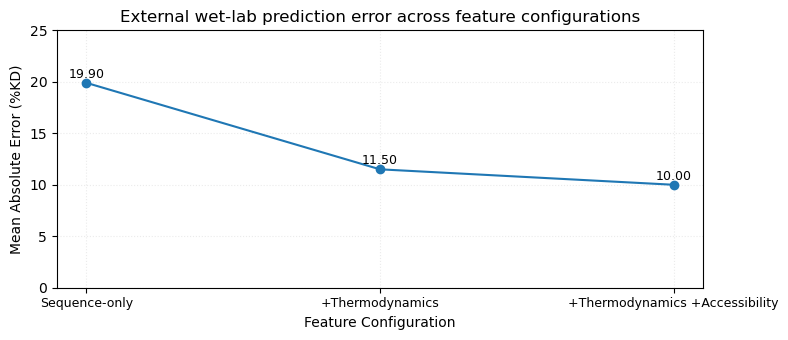

In [26]:
# ============================================================
# FIGURE 4 — Incremental contribution of biologically motivated features
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Final ablation values reported in the manuscript.
# These correspond to the sequence-only, thermodynamic,
# and thermodynamic + accessibility feature configurations.
fig4_csv = RESULTS_DIR_BASE / "fig4_ablation_values.csv"
df_fig4 = pd.read_csv(fig4_csv)

# Save numerical values underlying Figure 4
fig4_table_path = RESULTS_DIR_BASE / "fig4_feature_progression.csv"
fig4_table_path.parent.mkdir(parents=True, exist_ok=True)
df_fig4.to_csv(fig4_table_path, index=False)

# ---- Make figure ----
def wrap_label(s):
    return (
        s.replace(" (sim)", "\n(sim)")
         .replace(" + ", "\n+\n")
         .replace("anch", "anch.")
    )

x = np.arange(len(df_fig4))
mae = df_fig4["MAE_wetlab"].values

plt.figure(figsize=(8, 3.5))
valid = ~np.isnan(mae)
plt.ylim(0, 25)

plt.plot(
    x[valid],
    mae[valid],
    marker="o"
)

plt.xticks(
    x,
    [wrap_label(s) for s in df_fig4["short"]],
    fontsize=9
)

plt.ylabel("Mean Absolute Error (%KD)")
plt.xlabel("Feature Configuration")
plt.title("External wet-lab prediction error across feature configurations")
plt.grid(alpha=0.25, linestyle=":")

for i, v in enumerate(mae):
    if not np.isnan(v):
        plt.text(
            i,
            v + 0.2,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
fig4_path = FIG_DIR / "fig4_feature_progression.png"
plt.savefig(
    fig4_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()


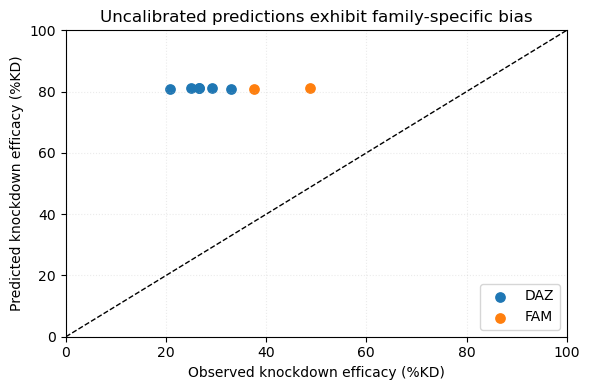

MAE: 50.12422183590486


In [27]:
# ============================================================
# FIGURE 5 — Phase 6 uncalibrated GBR predictions
# (single-panel scatter, MAE ≈ 32.75)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

required = {"KD_true_pct", "KD_pred_before_pct", "family"}
missing = required - set(pred8.columns)
if missing: raise RuntimeError(f"pred8 missing required columns: {missing}")

# --- compute MAE ---
mae_uncal = float(np.mean(np.abs(pred8["KD_true_pct"] - pred8["KD_pred_before_pct"])))

# --- plot ---
plt.figure(figsize=(6, 4))

family_colors = {
    "DAZ": "#1f77b4",
    "FAM": "#ff7f0e",
}

for fam, sub in pred8.groupby("family"):
    plt.scatter(
        sub["KD_true_pct"],
        sub["KD_pred_before_pct"],
        label=fam,
        s=45,
        color=family_colors.get(fam)
    )

# diagonal
plt.plot([0, 100], [0, 100], "k--", linewidth=1)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Observed knockdown efficacy (%KD)")
plt.ylabel("Predicted knockdown efficacy (%KD)")
plt.title("Uncalibrated predictions exhibit family-specific bias")
plt.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 0.0),
    frameon=True
)
plt.grid(alpha=0.25, linestyle=":")

plt.tight_layout()

out_path = FIG_DIR / "fig5_uncalibrated_gbr_predictions.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("MAE:", mae_uncal)


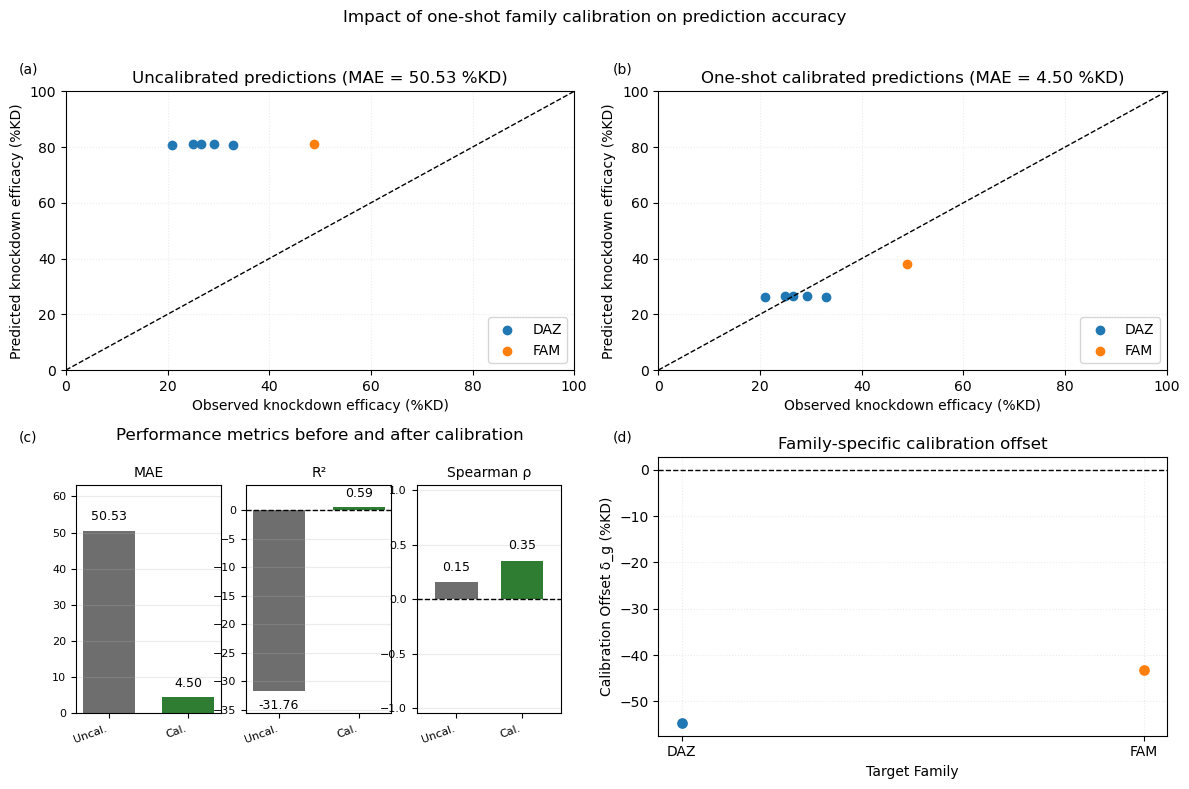

Saved: /mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/outputs/figures/fig6_phase6_calibration_impact.png


In [28]:
# ============================================================
#  Figure 6: Calibration impact (2×2)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pred8_eval = pred8.loc[~pred8["is_calibrator"]].copy()
order_fam = ["DAZ","FAM"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Impact of one-shot family calibration on prediction accuracy", y=0.98)
# ============================================================
# Panel labels
# ============================================================
fig.text(
    0.02, 0.90, "(a)",
    fontsize=10,
    fontweight="normal"
)
fig.text(
    0.515, 0.90, "(b)",
    fontsize=10,
    fontweight="normal"
)
fig.text(
    0.02, 0.44, "(c)",
    fontsize=10,
    fontweight="normal"
)
fig.text(
    0.515, 0.44, "(d)",
    fontsize=10,
    fontweight="normal"
)

# ---------------- Top-left: Before scatter ----------------
ax = axes[0, 0]
for fam, sub in pred8_eval.groupby("family"):
    ax.scatter(sub["KD_true_pct"], sub["KD_pred_before_pct"], label=fam)
ax.plot([0, 100], [0, 100], "k--", linewidth=1)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.grid(alpha=0.25, linestyle=":")
ax.set_title(
    f"Uncalibrated predictions "
    f"(MAE = {metrics_before['MAE']:.2f} %KD)"
)
ax.set_xlabel("Observed knockdown efficacy (%KD)")
ax.set_ylabel("Predicted knockdown efficacy (%KD)")
ax.legend(loc="lower right")

# ---------------- Top-right: After scatter ----------------
ax = axes[0, 1]
for fam, sub in pred8_eval.groupby("family"):
    ax.scatter(sub["KD_true_pct"], sub["KD_pred_after_pct"], label=fam)
ax.plot([0, 100], [0, 100], "k--", linewidth=1)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.grid(alpha=0.25, linestyle=":")
#ax.set_title(f"One-shot calibrated predictions (MAE = 4.59 %KD)")
ax.set_title(
    f"One-shot calibrated predictions "
    f"(MAE = {metrics_after['MAE']:.2f} %KD)"
)
ax.set_xlabel("Observed knockdown efficacy (%KD)")
ax.set_ylabel("Predicted knockdown efficacy (%KD)")
ax.legend(loc="lower right")

## ---------------- Bottom-left: Metrics shown on separate scales ----------------
# Keep this region as Panel C, but divide it into three internal mini-panels
# so MAE, predictive R², and Spearman rho each use an appropriate y-axis.

ax_parent = axes[1, 0]
ax_parent.clear()
ax_parent.axis("off")
ax_parent.set_title(
    "Performance metrics before and after calibration",
    pad=12
)

# Positions within the original Panel C:
# [left, bottom, width, height]
ax_mae = ax_parent.inset_axes([0.02, 0.08, 0.285, 0.82])
ax_r2  = ax_parent.inset_axes([0.355, 0.08, 0.285, 0.82])
ax_rho = ax_parent.inset_axes([0.69, 0.08, 0.285, 0.82])

bar_x = np.arange(2)
bar_labels = ["Uncal.", "Cal."]
#bar_colors = ["C0", "C1"]
bar_colors = ["#6E6E6E", "#2E7D32"] 

# ============================================================
# C1: MAE
# ============================================================
mae_values = [
    metrics_before["MAE"],
    metrics_after["MAE"],
]

bars = ax_mae.bar(
    bar_x,
    mae_values,
    color=bar_colors,
    width=0.65
)

ax_mae.set_title("MAE", fontsize=10)
ax_mae.set_xticks(bar_x)
ax_mae.set_xticklabels(bar_labels, rotation=20, ha="right")

mae_max = max(mae_values)
ax_mae.set_ylim(0, mae_max * 1.25)

for bar, value in zip(bars, mae_values):
    ax_mae.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + mae_max * 0.04,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax_mae.grid(axis="y", alpha=0.25)

# ============================================================
# C2: R²
# ============================================================
r2_values = [
    metrics_before["R2"],
    metrics_after["R2"],
]

bars = ax_r2.bar(
    bar_x,
    r2_values,
    color=bar_colors,
    width=0.65
)

ax_r2.set_title("R²", fontsize=10)
ax_r2.set_xticks(bar_x)
ax_r2.set_xticklabels(bar_labels, rotation=20, ha="right")
ax_r2.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

# Dynamic limits so the strongly negative uncalibrated R² remains visible
r2_min = min(r2_values)
r2_max = max(r2_values)
r2_range = max(r2_max - r2_min, 1.0)

lower_limit = min(-0.1, r2_min - 0.12 * r2_range)
upper_limit = max(1.0, r2_max + 0.12 * r2_range)

ax_r2.set_ylim(lower_limit, upper_limit)

for bar, value in zip(bars, r2_values):
    if value >= 0:
        y_text = value + 0.04 * r2_range
        va = "bottom"
    else:
        y_text = value - 0.04 * r2_range
        va = "top"

    ax_r2.text(
        bar.get_x() + bar.get_width() / 2,
        y_text,
        f"{value:.2f}",
        ha="center",
        va=va,
        fontsize=9,
    )

ax_r2.grid(axis="y", alpha=0.25)

# ============================================================
# C3: Spearman rho
# ============================================================
rho_before = metrics_before["Spearman"]
rho_after = metrics_after["Spearman"]

ax_rho.set_title("Spearman ρ", fontsize=10)
ax_rho.set_xticks([0, 1])
ax_rho.set_xlim(-0.6, 1.6)
ax_rho.set_xticklabels(
    ["Uncal.", "Cal."],
    rotation=20,
    ha="right"
)

# Natural correlation scale requested by reviewer
ax_rho.set_ylim(-1.05, 1.05)
ax_rho.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax_rho.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)
ax_rho.grid(axis="y", alpha=0.25)

# Uncalibrated Spearman is undefined because predictions are constant.
if np.isfinite(rho_before):
    bar_before = ax_rho.bar(
        0,
        rho_before,
        width=0.65,
        color=bar_colors[0]  
    )[0]

    y_before = (
        min(rho_before + 0.08, 0.96)
        if rho_before >= 0
        else max(rho_before - 0.08, -0.96)
    )

    ax_rho.text(
        bar_before.get_x() + bar_before.get_width() / 2,
        y_before,
        f"{rho_before:.2f}",
        ha="center",
        va="bottom" if rho_before >= 0 else "top",
        fontsize=9,
    )
else:
    ax_rho.text(
        0,
        0.08,
        "N/A",
        ha="center",
        va="center",
        fontsize=8,
        #fontweight="bold",
    )

# Plot calibrated Spearman only when finite
if np.isfinite(rho_after):
    bar_after = ax_rho.bar(
        1,
        rho_after,
        width=0.65,
        color=bar_colors[1] 
    )[0]

    y_after = (
        min(rho_after + 0.08, 0.96)
        if rho_after >= 0
        else max(rho_after - 0.08, -0.96)
    )

    ax_rho.text(
        bar_after.get_x() + bar_after.get_width() / 2,
        y_after,
        f"{rho_after:.2f}",
        ha="center",
        va="bottom" if rho_after >= 0 else "top",
        fontsize=9,
    )
for ax_metric in [ax_mae, ax_r2, ax_rho]:
    ax_metric.tick_params(axis="y", labelsize=8)
    ax_metric.tick_params(axis="x", labelsize=8)
    
# ---------------- Bottom-right: Family offsets ----------------
ax = axes[1, 1]
fam_offsets = [offsets.get(f, np.nan) for f in order_fam]
family_colors = {
    "DAZ": "#1f77b4",
    "FAM": "#ff7f0e",
}

for fam, offset in zip(order_fam, fam_offsets):
    ax.scatter(
        fam,
        offset,
        color=family_colors[fam],
        s=45,
        zorder=3,
    )
ax.axhline(0, color="k", linestyle="--", linewidth=1)
ax.set_title("Family-specific calibration offset")
ax.set_xlabel("Target Family")
ax.set_ylabel("Calibration Offset δ_g (%KD)")
ax.grid(alpha=0.25, linestyle=":")

plt.tight_layout(rect=[0, 0, 1, 0.96])

out_path = FIG_DIR / "fig6_phase6_calibration_impact.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out_path.resolve())

Sanity counts after normalization:
family
DAZ    6
FAM    2
Name: count, dtype: int64


/home/bguha/miniconda3/envs/astrocyte_sim/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/bguha/miniconda3/envs/astrocyte_sim/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,family,n,mae,mae_lo,mae_hi,r2,r2_lo,r2_hi,rho,rho_lo,rho_hi
0,DAZ,6,2.716276,0.784806,4.728500,-0.017620,-1.881933,0.074685,-0.185164,-1.0,0.866025
1,FAM,2,5.363460,0.000000,10.726919,-0.817427,-0.817427,-0.817427,NaN,NaN,NaN


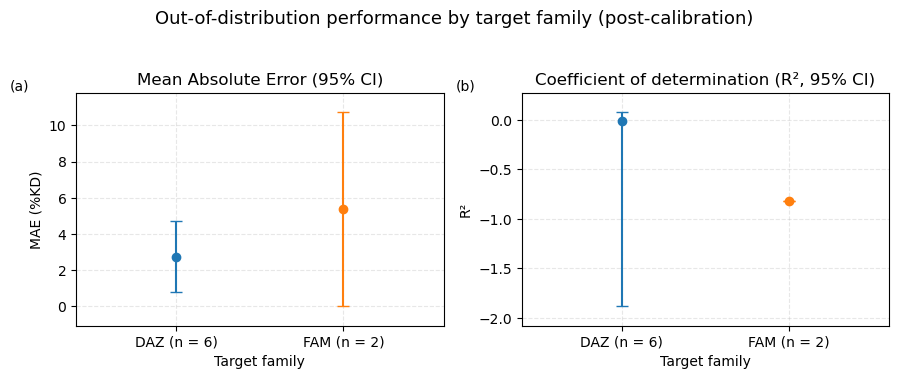

In [29]:
# ============================================================
# FIGURE 7  — OOD performance by target family
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# pred8 fresh (prevents stale state)
df = pred8.copy()

# 1) Choose the source label column (try 'family' first; fallback to gene-like labels)
# If your 'family' column is already DAZ/FAM, this does nothing harmful.
label_col = "family"
if label_col not in df.columns:
    raise KeyError("pred8 is missing a 'family' column. Check which column contains DAZ/FAM labels.")

# 2) Normalize to paper labels
df[label_col] = (
    df[label_col].astype(str).str.upper()
      .str.replace(r"^DAZ.*", "DAZ", regex=True)
      .str.replace(r"^FAM.*", "FAM", regex=True)
)

print("Sanity counts after normalization:")
print(df[label_col].value_counts())

# 3) Build met FROM THIS df 
def r2_score_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2:
        return np.nan
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return np.nan
    return 1.0 - (np.sum((y_true - y_pred)**2) / denom)

def spearman_rho_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 3:
        return np.nan
    rt = pd.Series(y_true).rank(method="average").to_numpy()
    rp = pd.Series(y_pred).rank(method="average").to_numpy()
    c = np.corrcoef(rt, rp)
    return float(c[0, 1]) if np.isfinite(c[0, 1]) else np.nan

def bootstrap_metric_ci(g, metric_fn, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    y = g["KD_true_pct"].to_numpy(dtype=float)
    p = g["KD_pred_after_pct"].to_numpy(dtype=float)

    point = metric_fn(y, p)

    vals = []
    n = len(g)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        v = metric_fn(y[idx], p[idx])
        vals.append(v)

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return point, np.nan, np.nan

    lo, hi = np.percentile(vals, [2.5, 97.5])
    return point, float(lo), float(hi)

MIN_N_MAE = 2
MIN_N_R2  = 2
MIN_N_RHO = 3  # set to 10 if you want rho panel empty like earlier

rows = []
for fam, g in df.groupby(label_col):
    g = g.dropna(subset=["KD_true_pct", "KD_pred_after_pct"])
    n = len(g)

    if n >= MIN_N_MAE:
        mae_fn = lambda yt, yp: float(np.mean(np.abs(yt - yp)))
        mae_pt, mae_lo, mae_hi = bootstrap_metric_ci(g, mae_fn, n_boot=5000, seed=1)
    else: mae_pt = mae_lo = mae_hi = np.nan

    if n >= MIN_N_R2: r2_pt, r2_lo, r2_hi = bootstrap_metric_ci(g, r2_score_safe, n_boot=5000, seed=2)
    else: r2_pt = r2_lo = r2_hi = np.nan

    if n >= MIN_N_RHO: rho_pt, rho_lo, rho_hi = bootstrap_metric_ci(g, spearman_rho_safe, n_boot=5000, seed=3)
    else: rho_pt = rho_lo = rho_hi = np.nan

    rows.append({
        "family": fam,
        "n": n,
        "mae": mae_pt, "mae_lo": mae_lo, "mae_hi": mae_hi,
        "r2": r2_pt, "r2_lo": r2_lo, "r2_hi": r2_hi,
        "rho": rho_pt, "rho_lo": rho_lo, "rho_hi": rho_hi,
    })

met = pd.DataFrame(rows).sort_values("family").reset_index(drop=True)
display(met)

# 4) Plot using ONLY met["family"] labels (no other columns)
FAMILY_COLORS = {"DAZ": "#1f77b4", "FAM": "#ff7f0e"}
families = met["family"].tolist()
x = np.arange(len(families))
xticklabels = [f"{fam} (n = {int(met.loc[i,'n'])})" for i, fam in enumerate(families)]

def padded_ylim(lo, hi, pad_frac=0.10):
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)
    ok = np.isfinite(lo) & np.isfinite(hi)
    if not np.any(ok):
        return None
    ymin, ymax = np.min(lo[ok]), np.max(hi[ok])
    if ymin == ymax:
        return (ymin - 1, ymax + 1)
    pad = (ymax - ymin) * pad_frac
    return (ymin - pad, ymax + pad)

def plot_err(ax, y, lo, hi, title, ylabel, ylim=None):
    for i, fam in enumerate(families):
        yi, loi, hii = y.iloc[i], lo.iloc[i], hi.iloc[i]
        if np.isfinite(yi) and np.isfinite(loi) and np.isfinite(hii):
            ax.errorbar(
                x[i], yi,
                yerr=[[yi - loi], [hii - yi]],
                fmt="o",
                color=FAMILY_COLORS.get(fam, "black"),
                capsize=4,
                markersize=6,
                linewidth=1.5,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel("Target family")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.3)
    # x padding so points aren't on borders
    ax.set_xlim(-0.6, len(families) - 1 + 0.6)

    if ylim is not None:
        ax.set_ylim(*ylim)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)

fig.suptitle(
    "Out-of-distribution performance by target family (post-calibration)",
    fontsize=13,
    y=1.04
)
# Panel labels
axes[0].text(
    -0.18, 1.06, "(a)",
    transform=axes[0].transAxes,
    fontsize=10,
    va="top",
)

axes[1].text(
    -0.18, 1.06, "(b)",
    transform=axes[1].transAxes,
    fontsize=10,
    va="top",
)
# Panel A: MAE
plot_err(
    axes[0],
    met["mae"],
    met["mae_lo"],
    met["mae_hi"],
    "Mean Absolute Error (95% CI)",
    "MAE (%KD)",
    ylim=padded_ylim(
        met["mae_lo"],
        met["mae_hi"],
        0.10
    )
)

# Panel B: R²
plot_err(
    axes[1],
    met["r2"],
    met["r2_lo"],
    met["r2_hi"],
    "Coefficient of determination (R², 95% CI)",
    "R²",
    ylim=padded_ylim(
        met["r2_lo"],
        met["r2_hi"],
        0.10
    )
)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CREATE SUPPLEMENTARY TABLE S5 FROM pred8
# Raw observed and predicted values underlying OOD evaluation
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Inspect available columns first
# ------------------------------------------------------------
print("Columns available in pred8:")
print(pred8.columns.tolist())

# ------------------------------------------------------------
# 2. Find the most likely ASO identifier column
# ------------------------------------------------------------
candidate_id_columns = [
    "ASO_ID",
    "aso_id",
    "ASO",
    "aso",
    "name",
    "Name",
    "sequence_id",
    "sample_id",
    "oligo_id",
    "wetlab_id",
]

aso_id_col = next(
    (col for col in candidate_id_columns if col in pred8.columns),
    None
)

if aso_id_col is None:
    print(
        "\nWARNING: No obvious ASO identifier column was found.\n"
        "Temporary row IDs will be created. You should replace these "
        "with the exact wet-lab ASO names before publication."
    )

    table_source = pred8.copy()
    table_source["ASO_ID"] = (
        table_source.groupby("family").cumcount() + 1
    )
    table_source["ASO_ID"] = (
        table_source["family"].astype(str)
        + "_ASO_"
        + table_source["ASO_ID"].astype(str)
    )
    aso_id_col = "ASO_ID"
else:
    table_source = pred8.copy()
    print(f"\nUsing ASO identifier column: {aso_id_col}")

# ------------------------------------------------------------
# 3. Normalize family labels
# ------------------------------------------------------------
table_source["family"] = (
    table_source["family"]
    .astype(str)
    .str.upper()
    .str.replace(r"^DAZ.*", "DAZ", regex=True)
    .str.replace(r"^FAM.*", "FAM", regex=True)
)

# ------------------------------------------------------------
# 4. Build Supplementary Table S5
# ------------------------------------------------------------
required_columns = [
    aso_id_col,
    "family",
    "KD_true_pct",
    "KD_pred_before_pct",
    "KD_pred_after_pct",
]

missing = [col for col in required_columns if col not in table_source.columns]

if missing:
    raise KeyError(
        "The following required columns are missing from pred8:\n"
        + "\n".join(missing)
    )

table_s5 = table_source[required_columns].copy()

table_s5 = table_s5.rename(
    columns={
        aso_id_col: "ASO ID",
        "family": "Target family",
        "KD_true_pct": "Observed knockdown (%KD)",
        "KD_pred_before_pct": "Uncalibrated predicted knockdown (%KD)",
        "KD_pred_after_pct": "One-shot calibrated predicted knockdown (%KD)",
    }
)

# Optional calibrator-status column
if "is_calibrator" in table_source.columns:
    table_s5["Role in one-shot calibration"] = np.where(
        table_source.loc[table_s5.index, "is_calibrator"].astype(bool),
        "Calibration reference",
        "Independent evaluation ASO",
    )

# ------------------------------------------------------------
# 5. Keep full-precision pred8 unchanged.
# ------------------------------------------------------------
numeric_columns = [
    "Observed knockdown (%KD)",
    "Uncalibrated predicted knockdown (%KD)",
    "One-shot calibrated predicted knockdown (%KD)",
]

table_s5[numeric_columns] = table_s5[numeric_columns].round(2)

# ------------------------------------------------------------
# 6. Sort table consistently
# ------------------------------------------------------------
family_order = pd.CategoricalDtype(
    categories=["DAZ", "FAM"],
    ordered=True
)

table_s5["Target family"] = table_s5["Target family"].astype(family_order)

table_s5 = (
    table_s5
    .sort_values(["Target family", "ASO ID"])
    .reset_index(drop=True)
)

# Convert back to text for clean CSV/Excel export
table_s5["Target family"] = table_s5["Target family"].astype(str)

# ------------------------------------------------------------
# 7. Display and verify
# ------------------------------------------------------------
display(table_s5)

print("\nRows in Supplementary Table S5:", len(table_s5))
print("\nFamily counts:")
print(table_s5["Target family"].value_counts())

# ------------------------------------------------------------
# 8. Save CSV and Excel files
# ------------------------------------------------------------
csv_path = SUPP_TABLE_DIR / "Supplementary_Table_S5_OOD_raw_values.csv"
xlsx_path = SUPP_TABLE_DIR / "Supplementary_Table_S5_OOD_raw_values.xlsx"

table_s5.to_csv(csv_path, index=False)
table_s5.to_excel(xlsx_path, index=False)

print("\nSaved CSV:")
print(csv_path.resolve())

print("\nSaved Excel:")
print(xlsx_path.resolve())

Columns available in pred8:
['aso_id', 'target', 'KD_true', 'KD_pred_LOOCV', 'mode', 'relative', 'alpha', 'neg_dG_bind_source', 'use_duplex', 'use_access', 'synthetic', 'synth_n_per_real', 'synth_weight', 'KD_true_pct', 'family', 'KD_pred_GBR', 'KD_pred_GBR_pct', 'KD_pred_before_pct', 'abs_err_before', 'is_calibrator', 'delta_g', 'KD_pred_after_pct', 'abs_err_after']

Using ASO identifier column: aso_id


,ASO ID,Target family,Observed knockdown (%KD),Uncalibrated predicted knockdown (%KD),One-shot calibrated predicted knockdown (%KD),Role in one-shot calibration
0,19,DAZ,32.97,80.84,26.16,Independent evaluation ASO
1,20,DAZ,20.89,80.84,26.16,Independent evaluation ASO
2,21,DAZ,26.56,81.23,26.55,Independent evaluation ASO
3,22,DAZ,24.98,81.23,26.55,Independent evaluation ASO
4,23,DAZ,26.55,81.23,26.55,Calibration reference
5,24,DAZ,29.18,81.23,26.55,Independent evaluation ASO
6,8,FAM,37.58,80.70,37.58,Calibration reference
7,10,FAM,48.83,81.23,38.11,Independent evaluation ASO



Rows in Supplementary Table S5: 8

Family counts:
Target family
DAZ    6
FAM    2
Name: count, dtype: int64

Saved CSV:
/mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/outputs/supplementary_tables/Supplementary_Table_S5_OOD_raw_values.csv

Saved Excel:
/mnt/c/Users/HP/Desktop/folder to test igem model sharing for Frontiers reviewers/igemModel copy/outputs/supplementary_tables/Supplementary_Table_S5_OOD_raw_values.xlsx


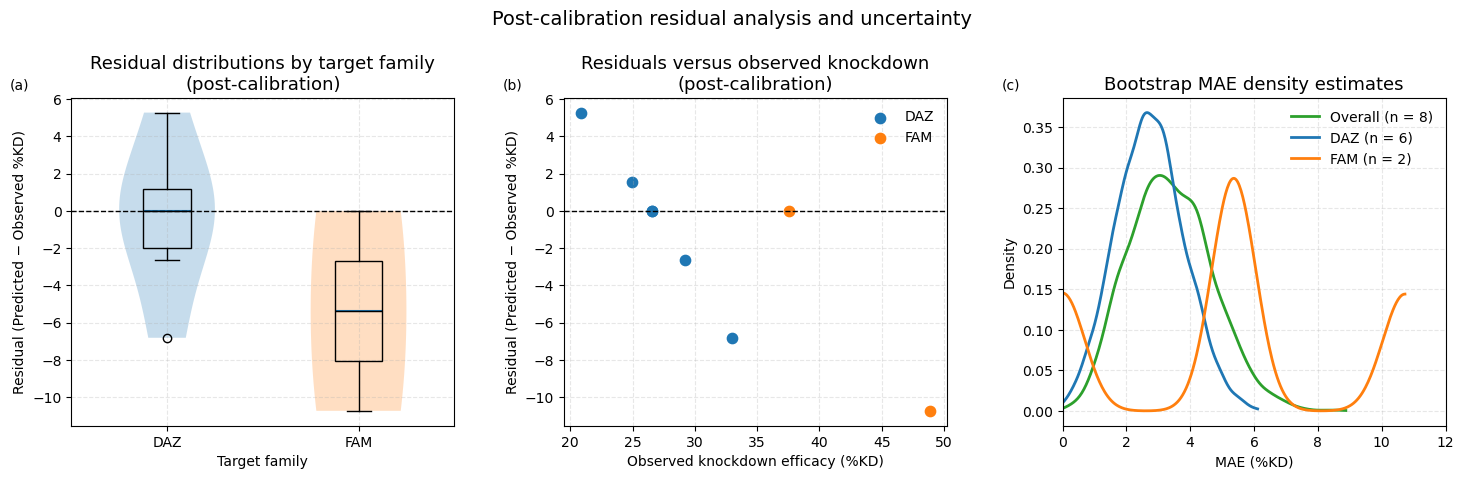

In [31]:
# ============================================================
# SUPPLEMENTARY FIGURE S7
# Post-calibration residual analysis and uncertainty
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Color consistency across OOD/calibration figures
FAMILY_COLORS = {"DAZ": "#1f77b4", "FAM": "#ff7f0e"}
OVERALL_COLOR = "#2ca02c"  # green for overall

df = pred8.copy()

# Normalize family labels if needed (ensures DAZ/FAM)
df["family"] = (
    df["family"].astype(str).str.upper()
      .str.replace(r"^DAZ.*", "DAZ", regex=True)
      .str.replace(r"^FAM.*", "FAM", regex=True)
)

# Residuals (Predicted - Observed)
df["residual"] = df["KD_pred_after_pct"] - df["KD_true_pct"]

# -----------------------------
# Helper: KDE plot
# -----------------------------
def plot_kde(ax, data, label, color):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) < 2:
        return
    kde = gaussian_kde(data)
    x = np.linspace(np.min(data), np.max(data), 400)
    ax.plot(x, kde(x), linewidth=2, color=color, label=label)

# -----------------------------
# Bootstrap MAE samples (used in Panel C)
# -----------------------------
def bootstrap_mae_samples(df_in, n_boot=5000, seed=0):
    df_in = df_in.dropna(subset=["KD_true_pct", "KD_pred_after_pct"])
    y = df_in["KD_true_pct"].to_numpy(dtype=float)
    p = df_in["KD_pred_after_pct"].to_numpy(dtype=float)
    n = len(df_in)
    if n == 0:
        return np.array([], dtype=float)

    rng = np.random.default_rng(seed)
    maes = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        maes[i] = np.mean(np.abs(y[idx] - p[idx]))
    return maes

boot_mae_all = bootstrap_mae_samples(df, n_boot=5000, seed=1)
boot_mae_daz = bootstrap_mae_samples(df[df["family"] == "DAZ"], n_boot=5000, seed=2)
boot_mae_fam = bootstrap_mae_samples(df[df["family"] == "FAM"], n_boot=5000, seed=3)

# -----------------------------
# Build multi-panel figure
# Use constrained_layout to prevent overlaps
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), constrained_layout=True)

# Global title (use suptitle; constrained_layout will pad for it)
fig.suptitle("Post-calibration residual analysis and uncertainty", fontsize=14, y=1.10)

# Give constrained_layout a bit more breathing room
fig.set_constrained_layout_pads(w_pad=2/72, h_pad=2/72, wspace=0.1, hspace=0.02)

# Common title style: wrap + smaller font to eliminate collisions
TITLE_FS = 13

# ============================================================
# Panel A — Residual distributions by family
# ============================================================
ax = axes[0]

daz = df.loc[df["family"] == "DAZ", "residual"].dropna().to_numpy()
fam = df.loc[df["family"] == "FAM", "residual"].dropna().to_numpy()

parts = ax.violinplot([daz, fam], positions=[0, 1], showmeans=False, showmedians=True, showextrema=False)
for i, body in enumerate(parts["bodies"]):
    fam_name = ["DAZ", "FAM"][i]
    body.set_facecolor(FAMILY_COLORS[fam_name])
    body.set_alpha(0.25)
    body.set_edgecolor("none")

ax.boxplot(
    [daz, fam],
    positions=[0, 1],
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor="none", color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
#ax.set_title("A: Residual distributions by target family\n(post-calibration)", fontsize=TITLE_FS)
ax.set_title("Residual distributions by target family\n(post-calibration)", fontsize=TITLE_FS)
axes[0].text(
    -0.16, 1.06, "(a)",
    transform=axes[0].transAxes,
    fontsize=10,
    fontweight="normal",
    va="top"
)
ax.set_xlabel("Target family")
ax.set_ylabel("Residual (Predicted − Observed %KD)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["DAZ", "FAM"])
ax.grid(True, linestyle="--", alpha=0.3)

# ============================================================
# Panel B — Residuals vs observed knockdown
# ============================================================
ax = axes[1]

for fam_name in ["DAZ", "FAM"]:
    g = df[df["family"] == fam_name].dropna(subset=["KD_true_pct", "residual"])
    ax.scatter(
        g["KD_true_pct"],
        g["residual"],
        s=55,
        color=FAMILY_COLORS[fam_name],
        label=fam_name
    )

ax.axhline(0, linestyle="--", color="black", linewidth=1)
#ax.set_title("B: Residuals versus observed knockdown\n(post-calibration)", fontsize=TITLE_FS)
ax.set_title("Residuals versus observed knockdown\n(post-calibration)", fontsize=TITLE_FS)
axes[1].text(
    -0.16, 1.06, "(b)",
    transform=axes[1].transAxes,
    fontsize=10,
    fontweight="normal",
    va="top"
)
ax.set_xlabel("Observed knockdown efficacy (%KD)")
ax.set_ylabel("Residual (Predicted − Observed %KD)")
ax.legend(frameon=False, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.3)

# ============================================================
# Panel C — Bootstrap MAE density estimates
# ============================================================
ax = axes[2]

plot_kde(ax, boot_mae_all, "Overall (n = 8)", OVERALL_COLOR)
plot_kde(ax, boot_mae_daz, "DAZ (n = 6)", FAMILY_COLORS["DAZ"])
plot_kde(ax, boot_mae_fam, "FAM (n = 2)", FAMILY_COLORS["FAM"])

#ax.set_title("C: Bootstrap MAE density estimates", fontsize=TITLE_FS)
ax.set_title("Bootstrap MAE density estimates", fontsize=TITLE_FS)
axes[2].text(
    -0.16, 1.06, "(c)",
    transform=axes[2].transAxes,
    fontsize=10,
    fontweight="normal",
    va="top"
)
ax.set_xlabel("MAE (%KD)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.3)

if len(boot_mae_all) > 0:
    ax.set_xlim(0, max(np.percentile(boot_mae_all, 99), 12))

out_path = FIG_DIR / "supp_fig_s7_post_calibration_residuals.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()


[INFO] Using X_eval: (22, 18) | y_eval: (22,)
[DEBUG] After NaN filtering: (22, 18) (22,)
[DEBUG] Baseline MAE: 0.016
[INFO] Features with ΔMAE > 0: 6


,feature,delta_mae,std
0,kmer5_PC3,0.108754,0.022044
1,kmer6_PC3,0.086314,0.018702
2,kmer5_PC1,0.038892,0.007725
3,kmer5_PC2,0.036484,0.007042
4,kmer6_PC2,0.027041,0.005278
5,kmer6_PC1,0.011451,0.004177


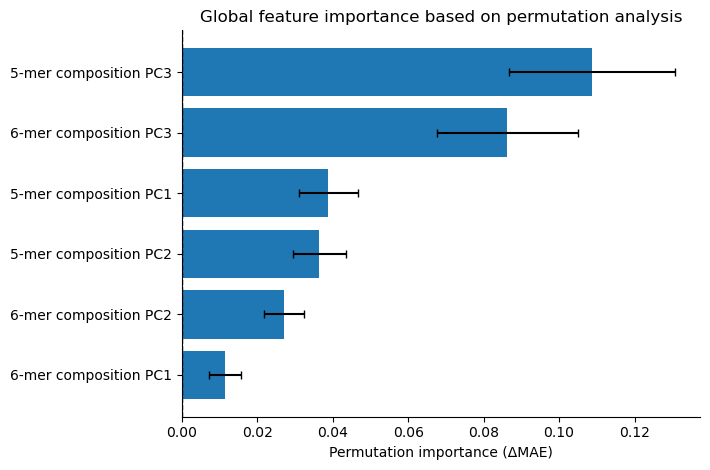

In [32]:
# ============================================================
# FIG 8 — Global feature importance based on permutation analysis
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, make_scorer

# -----------------------------
# Bind model + dataset
# -----------------------------
# Use your trained Phase-6 model (you have both gbr and model; pick one explicitly)
gbr_model = gbr  # or: gbr_model = model

# Permutation importance is evaluated on the literature training distribution.
X_eval = X_train.copy()
y_eval = np.asarray(y_train, dtype=float)

# Ensure feature order matches training
feature_cols = list(gbr_model.feature_names_in_)
X_eval = X_eval[feature_cols].copy()

print("[INFO] Using X_eval:", X_eval.shape, "| y_eval:", y_eval.shape)

# Drop NaNs consistently
mask = np.isfinite(y_eval) & np.isfinite(X_eval.to_numpy(dtype=float)).all(axis=1)
X_eval = X_eval.loc[mask].reset_index(drop=True)
y_eval = y_eval[mask]

print("[DEBUG] After NaN filtering:", X_eval.shape, y_eval.shape)
if len(X_eval) == 0:
    raise RuntimeError("No samples remain after NaN filtering.")

# -----------------------------
# Baseline MAE (debug)
# -----------------------------
y_pred = gbr_model.predict(X_eval)
baseline_mae = mean_absolute_error(y_eval, y_pred)
print(f"[DEBUG] Baseline MAE: {baseline_mae:.3f}")

# -----------------------------
# Permutation importance (ΔMAE)
# -----------------------------
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

perm = permutation_importance(
    estimator=gbr_model,
    X=X_eval,
    y=y_eval,
    scoring=mae_scorer,
    n_repeats=200,      # more stable than 50 for small-ish n
    random_state=42,
    n_jobs=-1
)

delta = perm.importances_mean
std = perm.importances_std

imp = pd.DataFrame({
    "feature": feature_cols,
    "delta_mae": delta,
    "std": std
})

# -----------------------------
# Keep only ΔMAE > 0 and sort
# -----------------------------
imp_pos = imp.loc[imp["delta_mae"] > 0].copy()
imp_pos = imp_pos.sort_values("delta_mae", ascending=False).reset_index(drop=True)

print(f"[INFO] Features with ΔMAE > 0: {len(imp_pos)}")
display(imp_pos)

if len(imp_pos) == 0:
    raise RuntimeError("No features have ΔMAE > 0. (This can happen with tiny eval sets.)")

# -----------------------------
# Rename y-axis labels (kmer PCs)
# -----------------------------
def pretty_feature_name(f: str) -> str:
    f = str(f)
    # kmer5_PC3 -> 5-mer composition PC3
    if f.startswith("kmer5_PC"):
        pc = f.replace("kmer5_PC", "")
        return f"5-mer composition PC{pc}"
    if f.startswith("kmer6_PC"):
        pc = f.replace("kmer6_PC", "")
        return f"6-mer composition PC{pc}"
    return f  # leave others as-is

imp_pos["feature_pretty"] = imp_pos["feature"].apply(pretty_feature_name)

# -----------------------------
# Plot (only positive importances)
# -----------------------------
# Reverse for barh: largest at top
plot_df = imp_pos.iloc[::-1].copy()

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.barh(
    plot_df["feature_pretty"],
    plot_df["delta_mae"],
    xerr=plot_df["std"],
    capsize=3
)

ax.set_title("Global feature importance based on permutation analysis")
ax.set_xlabel("Permutation importance (ΔMAE)")
ax.set_ylabel("")

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()

out_path = FIG_DIR / "fig8_global_feature_importance.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

imp_path = RESULTS_DIR_BASE / "fig8_permutation_importance.csv"
imp_pos.to_csv(imp_path, index=False)
